<a href="https://colab.research.google.com/github/lucmos2002/workshopGITHUB/blob/master/TCC_Lucas_Souza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title
!pip install tabula-py

In [ ]:
import pandas as pd
import tabula
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Importação dos Dados da Cesta Básica
cesta_bh = pd.read_excel('/content/BH_DIEESE_Cesta.xls',header=1)
cesta_rj = pd.read_excel('/content/RJ_DIEESE_Cesta.xls',header=1)
cesta_sp = pd.read_excel('/content/SP_DIEESE_Cesta.xls',header=1)
cesta_es = pd.read_excel('/content/VIT_DIEESE_Cesta.xls',header=1)

cesta_bh.rename(columns={'Unnamed: 0':'Período','Total da Cesta':'Total_Belo Horizonte'},inplace=True)
cesta_rj.rename(columns={'Unnamed: 0':'Período','Total da Cesta':'Total_Rio de Janeiro'},inplace=True)
cesta_sp.rename(columns={'Unnamed: 0':'Período','Total da Cesta':'Total_São Paulo'},inplace=True)
cesta_es.rename(columns={'Unnamed: 0':'Período','Total da Cesta':'Total_Espírito Santo'},inplace=True)

In [ ]:
cesta_sp[['Mês','Ano']] = cesta_sp['Período'].str.split('-',expand=True)

cesta_sp['Data'] = pd.to_datetime(cesta_sp['Mês'] + '-' + cesta_sp['Ano'])

cesta_sp.drop(columns=['Período','Mês','Ano'],inplace=True)

cesta_sp.set_index('Data',inplace=True)

cesta_sp = cesta_sp['Total_São Paulo']

cesta_sp.head()
#

/tmp/ipykernel_2960/4111380068.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cesta_sp['Data'] = pd.to_datetime(cesta_sp['Mês'] + '-' + cesta_sp['Ano'])


,Total_São Paulo
Data,
2020-01-01,517.51
2020-02-01,519.76
2020-03-01,518.50
2020-04-01,556.25
2020-05-01,556.36


In [ ]:
cesta_bh[['Mês','Ano']] = cesta_bh['Período'].str.split('-',expand=True)

cesta_bh['Data'] = pd.to_datetime(cesta_bh['Mês'] + '-' + cesta_bh['Ano'])

cesta_bh.drop(columns=['Período','Mês','Ano'],inplace=True)

cesta_bh.set_index('Data',inplace=True)

cesta_bh = cesta_bh['Total_Belo Horizonte']

cesta_bh.head()

/tmp/ipykernel_2960/2459396266.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cesta_bh['Data'] = pd.to_datetime(cesta_bh['Mês'] + '-' + cesta_bh['Ano'])


,Total_Belo Horizonte
Data,
2020-01-01,456.35
2020-02-01,459.10
2020-03-01,461.28
2020-04-01,484.55
2020-05-01,484.02


In [ ]:
cesta_rj[['Mês','Ano']] = cesta_rj['Período'].str.split('-',expand=True)

cesta_rj['Data'] = pd.to_datetime(cesta_rj['Mês'] + '-' + cesta_rj['Ano'])

cesta_rj.drop(columns=['Período','Mês','Ano'],inplace=True)

cesta_rj.set_index('Data',inplace=True)

cesta_rj = cesta_rj['Total_Rio de Janeiro']

cesta_rj.head()

/tmp/ipykernel_2960/3277228403.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cesta_rj['Data'] = pd.to_datetime(cesta_rj['Mês'] + '-' + cesta_rj['Ano'])


,Total_Rio de Janeiro
Data,
2020-01-01,507.13
2020-02-01,505.55
2020-03-01,533.65
2020-04-01,544.34
2020-05-01,558.81


In [ ]:
cesta_es[['Mês','Ano']] = cesta_es['Período'].str.split('-',expand=True)

cesta_es['Data'] = pd.to_datetime(cesta_es['Mês'] + '-' + cesta_es['Ano'])

cesta_es.drop(columns=['Período','Mês','Ano'],inplace=True)

cesta_es.set_index('Data',inplace=True)

cesta_es = cesta_es['Total_Espírito Santo']

cesta_es.head()

/tmp/ipykernel_2960/2050335508.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cesta_es['Data'] = pd.to_datetime(cesta_es['Mês'] + '-' + cesta_es['Ano'])


,Total_Espírito Santo
Data,
2020-01-01,492.20
2020-02-01,480.03
2020-03-01,504.78
2020-04-01,537.89
2020-05-01,536.73


In [ ]:
cesta_es = cesta_es.reset_index()
cesta_bh = cesta_bh.reset_index()
cesta_rj = cesta_rj.reset_index()
cesta_sp = cesta_sp.reset_index()

In [ ]:
cestas = [cesta_bh,cesta_rj,cesta_sp,cesta_es]

cesta_def = pd.concat(cestas,axis=1,join='inner')

cesta_def.index = pd.to_datetime(cesta_def['Data'].iloc[:, 0])

cesta_def = cesta_def.drop(columns=['Data'])

cesta_def.head()

,Total_Belo Horizonte,Total_Rio de Janeiro,Total_São Paulo,Total_Espírito Santo
Data,,,,
2020-01-01,456.35,507.13,517.51,492.20
2020-02-01,459.10,505.55,519.76,480.03
2020-03-01,461.28,533.65,518.50,504.78
2020-04-01,484.55,544.34,556.25,537.89
2020-05-01,484.02,558.81,556.36,536.73


In [ ]:
cesta_def = cesta_def.interpolate(method='linear',axis=0)

cesta_def.head()

,Total_Belo Horizonte,Total_Rio de Janeiro,Total_São Paulo,Total_Espírito Santo
Data,,,,
2020-01-01,456.35,507.13,517.51,492.20
2020-02-01,459.10,505.55,519.76,480.03
2020-03-01,461.28,533.65,518.50,504.78
2020-04-01,484.55,544.34,556.25,537.89
2020-05-01,484.02,558.81,556.36,536.73


In [ ]:
cesta_def.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 64 entries, 2020-01-01 to NaT
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Total_Belo Horizonte  64 non-null     float64
 1   Total_Rio de Janeiro  64 non-null     float64
 2   Total_São Paulo       64 non-null     float64
 3   Total_Espírito Santo  64 non-null     float64
dtypes: float64(4)
memory usage: 2.5 KB


In [ ]:
import locale
import datetime

In [ ]:
#Importação dos Dados da Inflação

infl= pd.read_csv('/content/SérieHistórica_Inflação.csv',sep=';',skiprows=1,header=0)

infl_long = infl.melt(var_name='Mes_Ano', value_name='Variacao_Inflacao')

infl_long.dropna(inplace=True)

infl_long.drop(index=0,inplace=True)

infl_long.drop(index=1,inplace=True)

infl_long.reset_index(drop=True,inplace=True)

import pandas as pd

# Dicionário de tradução
meses_map = {
    'janeiro': '01', 'fevereiro': '02', 'março': '03', 'abril': '04',
    'maio': '05', 'junho': '06', 'julho': '07', 'agosto': '08',
    'setembro': '09', 'outubro': '10', 'novembro': '11', 'dezembro': '12'
}

# Supondo que df_long['Mes_Ano'] seja "maio 2000"
infl_long[['mes_extenso', 'ano']] = infl_long['Mes_Ano'].str.split(' ', expand=True)

infl_long['mes_num'] = infl_long['mes_extenso'].str.lower().map(meses_map)

# Cria a coluna data real
infl_long['Data'] = pd.to_datetime(infl_long['mes_num'] + '-' + infl_long['ano'])

infl_long.drop(columns=['Mes_Ano','mes_extenso','ano','mes_num'],inplace=True)

infl_long.tail(10)

/tmp/ipykernel_2960/3562717363.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  infl_long['Data'] = pd.to_datetime(infl_long['mes_num'] + '-' + infl_long['ano'])


,Variacao_Inflacao,Data
300,0.36,2025-05-01
301,0.26,2025-06-01
302,0.33,2025-07-01
303,-0.14,2025-08-01
304,0.48,2025-09-01
305,0.18,2025-10-01
306,0.2,2025-11-01
307,0.25,2025-12-01
308,0.2,2026-01-01
309,0.84,2026-02-01


In [ ]:
import pandas as pd

# 1. Garantir que a data está no formato correto e ordenada
infl_long['Data'] = pd.to_datetime(infl_long['Data'])
df_infl = infl_long.sort_values('Data').reset_index(drop=True)

# 2. Transformar a variação em fator (Ex: 0.5% vira 1.005)
# Se o seu dado já for decimal (0.005), use apenas: df['Fator'] = 1 + df['Variacao_Inflacao']
df_infl['Fator'] = 1 + (df_infl['Variacao_Inflacao'] / 100)

# 3. Calcular a série temporal cumulativa (Número Índice desde 2000)
df_infl['Indice_Acumulado'] = df_infl['Fator'].cumprod()

# 4. Fazer o recorte exato para o período do seu TCC (2020 a 2025)
# Incluindo dezembro de 2025 completo
df_infl = df_infl[(df_infl['Data'] >= '2020-01-01') & (df_infl['Data'] <= '2025-12-01')].copy()

# 5. O PULO DO GATO: Rebasear para que Janeiro de 2020 seja o marco zero (Índice = 100)
# Isso mantém a proporcionalidade exata do passado, mas limpa a escala visual
valor_base_2020 = df_infl.iloc[0]['Indice_Acumulado']
df_infl['Indice_Preco_Base2020'] = (df_infl['Indice_Acumulado'] / valor_base_2020) * 100

df_infl.set_index('Data',inplace=True)

df_infl.head()

,Variacao_Inflacao,Fator,Indice_Acumulado,Indice_Preco_Base2020
Data,,,,
2020-01-01,0.71,1.0071,3.313062,100.0
2020-02-01,0.22,1.0022,3.320351,100.22
2020-03-01,0.02,1.0002,3.321015,100.240044
2020-04-01,-0.01,0.9999,3.320683,100.23002
2020-05-01,-0.59,0.9941,3.301091,99.638663


In [ ]:
df_infl.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 72 entries, 2020-01-01 to 2025-12-01
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Variacao_Inflacao      72 non-null     object
 1   Fator                  72 non-null     object
 2   Indice_Acumulado       72 non-null     object
 3   Indice_Preco_Base2020  72 non-null     object
dtypes: object(4)
memory usage: 2.8+ KB


In [ ]:
!pip install pypdf

In [ ]:
import re
import numpy as np
import pandas as pd
import pypdf

caminho_pdf = '/content/Índice Fipezap - Fundação Instituto de Pesquisas Econômicas - Fipe_RJ_SP_ES.pdf'

# 1. LEITURA DIRETA DO TEXTO COM PYPDF (Sem dependência do Tabula)
reader = pypdf.PdfReader(caminho_pdf)
dados_extraidos = []
ano_atual = None

# Expressão regular para capturar meses e os blocos de números que os seguem
regex_linha = re.compile(r'([a-zA-ZáéíóúÁÉÍÓÚçÇ]{3,4})\b\s*(.*)')

for i, page in enumerate(reader.pages):
    try:
        # Extrai o texto puro da página diretamente do buffer do PDF
        texto_pagina = page.extract_text()
        if not texto_pagina:
            continue

        # Divide o texto em linhas simples
        linhas = texto_pagina.split('\n')

        for linha in linhas:
            linha_texto = linha.strip()

            # Identificar o Ano na linha (ex: 2024)
            match_ano = re.match(r'^(\d{4})$', linha_texto)
            if match_ano:
                ano_atual = match_ano.group(1)
                continue

            # Se temos um ano definido, tentamos extrair o mês e os valores
            match_dados = regex_linha.search(linha_texto)
            if match_dados and ano_atual:
                mes = match_dados.group(1).lower().strip()
                resto = match_dados.group(2)

                # Limpeza preserving a vírgula decimal
                resto_limpo = re.sub(r'[\"\'\r\n\\]+', ' ', resto)

                # Regex que aceita números com vírgula ou ponto decimal
                valores = re.findall(r'\d+[\.,]?\d*', resto_limpo)

                # Converte vírgula em ponto para leitura do Python
                valores = [v.replace(',', '.') for v in valores]

                if valores:
                    dados_extraidos.append({
                        'Ano': ano_atual,
                        'Mês': mes,
                        'Valores_Brutos': valores
                    })

    except Exception as e:
        print(f"Erro na página {i + 1}: {e}")

# 2. RECONSTRUÇÃO DO DATAFRAME PARSEADO
registros_finais = []

for dado in dados_extraidos:
    v = dado['Valores_Brutos']

    # Mapeamento posicional seguro (RJ, SP, VIT)
    rj = v[0] if len(v) > 0 else np.nan
    sp = v[1] if len(v) > 1 else np.nan
    vit = v[2] if len(v) > 2 else np.nan

    registros_finais.append({
        'Ano': dado['Ano'],
        'Mês': dado['Mês'],
        'Rio de Janeiro': rj,
        'São Paulo': sp,
        'Vitória': vit
    })

df_fipe = pd.DataFrame(registros_finais)

# 3. MAPEAMENTO DE DATAS
meses_map = {
    'jan': 1, 'fev': 2, 'mar': 3, 'abr': 4, 'mai': 5, 'jun': 6,
    'jul': 7, 'ago': 8, 'set': 9, 'out': 10, 'nov': 11, 'dez': 12
}
df_fipe['Mes_Num'] = df_fipe['Mês'].str.strip().str[:3].map(meses_map)
df_fipe = df_fipe.dropna(subset=['Mes_Num', 'Ano'])

df_fipe['Data'] = pd.to_datetime(df_fipe['Ano'].astype(str) + '-' + df_fipe['Mes_Num'].astype(int).astype(str) + '-01')
df_fipe = df_fipe.set_index('Data').sort_index()

# 4. TRATAMENTO NUMÉRICO FINAL
colunas_valores = ['Rio de Janeiro', 'São Paulo', 'Vitória']
for col in colunas_valores:
    df_fipe[col] = pd.to_numeric(df_fipe[col], errors='coerce')

# 5. RECORTE TEMPORAL DO TCC
df_fipe_filtrado = df_fipe[colunas_valores].loc['2020-01-01':'2025-12-01']

print("Shape final da base FipeZap:", df_fipe_filtrado.shape)
df_fipe_filtrado.head(15)

Shape final da base FipeZap: (70, 3)


,Rio de Janeiro,São Paulo,Vitória
Data,,,
2020-01-01,131.66,153.02,NaN
2020-02-01,132.17,154.09,NaN
2020-03-01,133.08,156.04,NaN
2020-04-01,133.62,158.31,NaN
2020-05-01,133.42,159.33,NaN
2020-06-01,132.55,158.90,NaN
2020-07-01,131.68,157.49,NaN
2020-08-01,131.29,156.21,NaN
2020-09-01,130.99,155.35,NaN


In [ ]:
import re
import numpy as np
import pandas as pd
import pypdf

caminho_pdf = '/content/Índice Fipezap - Fundação Instituto de Pesquisas Econômicas - Fipe_RJ_SP_ES.pdf'

reader = pypdf.PdfReader(caminho_pdf)
dados_extraidos = []
ano_atual = None

# Mapeamento estrito de meses válidos
meses_validos = ['jan', 'fev', 'mar', 'abr', 'mai', 'jun', 'jul', 'ago', 'set', 'out', 'nov', 'dez']

for i, page in enumerate(reader.pages):
    texto = page.extract_text()
    if not texto:
        continue

    linhas = texto.split('\n')

    for linha in linhas:
        linha_limpa = linha.strip()
        if not linha_limpa:
            continue

        # 1. Identifica o Ano (linha contendo apenas 4 dígitos)
        match_ano = re.match(r'^(\d{4})$', linha_limpa)
        if match_ano:
            ano_atual = match_ano.group(1)
            continue

        # 2. Processa as linhas de dados se o ano já foi identificado
        if ano_atual:
            # Busca se existe algum mês válido na linha (independente da posição)
            mes_encontrado = None
            for m in meses_validos:
                if re.search(r'\b' + m + r'\b', linha_limpa, re.IGNORECASE):
                    mes_encontrado = m
                    break

            if mes_encontrado:
                # Extrai todos os números flutuantes (com vírgula ou ponto)
                # Removemos a palavra do mês para não interferir na busca numérica
                linha_sem_mes = re.sub(r'\b' + mes_encontrado + r'\b', '', linha_limpa, flags=re.IGNORECASE)

                # Captura padrões numéricos como 228,72 ou 169.47
                valores_brutos = re.findall(r'\d+[\.,]\d+', linha_sem_mes)
                valores_convertidos = [v.replace(',', '.') for v in valores_brutos]

                if valores_convertidos:
                    dados_extraidos.append({
                        'Ano': ano_atual,
                        'Mês': mes_encontrado,
                        'Valores': valores_convertidos
                    })

# 3. RECONSTRUÇÃO DO DATAFRAME
registros_finais = []

for dado in dados_extraidos:
    v = dado['Valores']

    # Mapeamento dinâmico baseado na quantidade de valores capturados na linha
    # 2020/2021 contêm 2 valores (RJ, SP) | 2022+ contêm 3 valores (RJ, SP, VIT)
    rj = v[0] if len(v) > 0 else np.nan
    sp = v[1] if len(v) > 1 else np.nan
    vit = v[2] if len(v) > 2 else np.nan

    registros_finais.append({
        'Ano': dado['Ano'],
        'Mês': dado['Mês'],
        'Rio de Janeiro': rj,
        'São Paulo': sp,
        'Vitória': vit
    })

df_fipe = pd.DataFrame(registros_finais)

# 4. TRATAMENTO DE DATAS E ÍNDICE
meses_map = {
    'jan': 1, 'fev': 2, 'mar': 3, 'abr': 4, 'mai': 5, 'jun': 6,
    'jul': 7, 'ago': 8, 'set': 9, 'out': 10, 'nov': 11, 'dez': 12
}

df_fipe['Mes_Num'] = df_fipe['Mês'].map(meses_map)
df_fipe['Data'] = pd.to_datetime(df_fipe['Ano'].astype(str) + '-' + df_fipe['Mes_Num'].astype(str) + '-01')
df_fipe = df_fipe.set_index('Data').sort_index()

# 5. TRATAMENTO NUMÉRICO FINAL E FILTRO TEMPORAL DO TCC
colunas_valores = ['Rio de Janeiro', 'São Paulo', 'Vitória']
for col in colunas_valores:
    df_fipe[col] = pd.to_numeric(df_fipe[col], errors='coerce')

df_fipe_filtrado = df_fipe[colunas_valores].loc['2020-01-01':'2025-12-01']

print("Shape final da base FipeZap:", df_fipe_filtrado.shape)
df_fipe_filtrado.head(15)

Shape final da base FipeZap: (70, 3)


,Rio de Janeiro,São Paulo,Vitória
Data,,,
2020-01-01,131.66,153.02,NaN
2020-02-01,132.17,154.09,NaN
2020-03-01,133.08,156.04,NaN
2020-04-01,133.62,158.31,NaN
2020-05-01,133.42,159.33,NaN
2020-06-01,132.55,158.90,NaN
2020-07-01,131.68,157.49,NaN
2020-08-01,131.29,156.21,NaN
2020-09-01,130.99,155.35,NaN


Coerência de Mercado: O mercado imobiliário de uma capital não se move de forma isolada; ele dita e acompanha a tendência das cidades satélites (como Vila Velha, Serra e Cariacica).

O Fator de Escala: Como o FipeZap é um número índice, a variação percentual do estado é o que realmente importa para a Granger, e não o valor absoluto. Assumir que Vitória variou de forma semelhante ao agregado do ES na crise de 2020 é uma premissa perfeitamente aceitável em modelos macroeconômicos na ausência de dados municipai

Backcasting

In [ ]:
# 1. Calcular a matriz de correlação no período em que Vitória tem dados (2022-2025)
periodo_comum = df_fipe_filtrado.loc['2022-01-01':'2025-12-01']
correlacao = periodo_comum.corr()
print("Matriz de Correlação:\n", correlacao['Vitória'])

# 2. Supondo que o Rio de Janeiro teve a maior correlação, usamos a sua taxa de variação.
# Calculamos a variação percentual mensal do Rio de Janeiro para toda a série
df_fipe_filtrado['Var_RJ'] = df_fipe_filtrado['Rio de Janeiro'].pct_change()

# 3. Criamos a coluna final de Vitória. Inicialmente ela recebe os dados reais.
df_fipe_filtrado['Vitória_Sintética'] = df_fipe_filtrado['Vitória']

# 4. Loop invertido: partimos de janeiro de 2022 e vamos calculando os meses anteriores
# aplicando a mesma variação que o Rio de Janeiro sofreu, mas em sentido inverso.
datas_vazias = df_fipe_filtrado.loc['2020-01-01':'2021-12-01'].index[::-1] # Do fim de 2021 para o início de 2020

for i in range(len(datas_vazias)):
    data_atual = datas_vazias[i]

    # Descobrir a data imediatamente posterior (que já tem valor populado)
    if i == 0:
        data_posterior = pd.Timestamp('2022-01-01')
    else:
        data_posterior = datas_vazias[i-1]

    # O valor anterior é o valor posterior dividido por (1 + variação da referência)
    var_ref = df_fipe_filtrado.loc[data_posterior, 'Var_RJ']
    df_fipe_filtrado.loc[data_atual, 'Vitória_Sintética'] = df_fipe_filtrado.loc[data_posterior, 'Vitória_Sintética'] / (1 + var_ref)

Matriz de Correlação:
 Rio de Janeiro    0.976401
São Paulo         0.965509
Vitória           1.000000
Name: Vitória, dtype: float64


In [ ]:
df_fipe_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 70 entries, 2020-01-01 to 2025-10-01
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rio de Janeiro     70 non-null     float64
 1   São Paulo          70 non-null     float64
 2   Vitória            46 non-null     float64
 3   Var_RJ             69 non-null     float64
 4   Vitória_Sintética  70 non-null     float64
dtypes: float64(5)
memory usage: 5.3 KB


In [ ]:
df_fipe.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 130 entries, 2015-01-01 to 2025-10-01
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Ano             130 non-null    object 
 1   Mês             130 non-null    object 
 2   Rio de Janeiro  130 non-null    float64
 3   São Paulo       130 non-null    float64
 4   Vitória         46 non-null     float64
 5   Mes_Num         130 non-null    int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 11.2+ KB


In [ ]:
import re
import numpy as np
import pandas as pd
import pypdf

caminho_pdf2 = '/content/Índice Fipezap - Fundação Instituto de Pesquisas Econômicas - Fipe_MG.pdf'

# 1. LEITURA DIRETA DO TEXTO COM PYPDF (Sem dependência do Tabula)
reader = pypdf.PdfReader(caminho_pdf2)
dados_extraidos = []
ano_atual = None

# Mapeamento estrito de meses válidos para a busca flexível
meses_validos = ['jan', 'fev', 'mar', 'abr', 'mai', 'jun', 'jul', 'ago', 'set', 'out', 'nov', 'dez']

for i, page in enumerate(reader.pages):
    texto = page.extract_text()
    if not texto:
        continue

    linhas = texto.split('\n')

    for linha in linhas:
        linha_limpa = linha.strip()
        if not linha_limpa:
            continue

        # Identifica o Ano (linha contendo apenas 4 dígitos isolados)
        match_ano = re.match(r'^(\d{4})$', linha_limpa)
        if match_ano:
            ano_atual = match_ano.group(1)
            continue

        # Processa a linha se o ano já foi identificado
        if ano_atual:
            # Busca se existe algum mês válido na linha
            mes_encontrado = None
            for m in meses_validos:
                if re.search(r'\b' + m + r'\b', linha_limpa, re.IGNORECASE):
                    mes_encontrado = m
                    break

            if mes_encontrado:
                # Remove o nome do mês para isolar os blocos numéricos
                linha_sem_mes = re.sub(r'\b' + mes_encontrado + r'\b', '', linha_limpa, flags=re.IGNORECASE)

                # Extrai os números decimais (com ponto ou vírgula)
                valores_brutos = re.findall(r'\d+[\.,]\d+', linha_sem_mes)
                valores_convertidos = [v.replace(',', '.') for v in valores_brutos]

                if valores_convertidos:
                    dados_extraidos.append({
                        'Ano': ano_atual,
                        'Mês': mes_encontrado,
                        'Valores': valores_convertidos
                    })

# 2. RECONSTRUÇÃO DO DATAFRAME PARSEADO (BELO HORIZONTE)
registros_finais = []

for dado in dados_extraidos:
    v = dado['Valores']

    # Como a tabela de MG refere-se a BH, capturamos a primeira posição numérica válida
    bh = v[0] if len(v) > 0 else np.nan

    registros_finais.append({
        'Ano': dado['Ano'],
        'Mês': dado['Mês'],
        'Belo Horizonte': bh
    })

df_fipe2 = pd.DataFrame(registros_finais)

# 3. MAPEAMENTO DE DATAS E ÍNDICE
meses_map = {
    'jan': 1, 'fev': 2, 'mar': 3, 'abr': 4, 'mai': 5, 'jun': 6,
    'jul': 7, 'ago': 8, 'set': 9, 'out': 10, 'nov': 11, 'dez': 12
}

df_fipe2['Mes_Num'] = df_fipe2['Mês'].map(meses_map)
df_fipe2['Data'] = pd.to_datetime(df_fipe2['Ano'].astype(str) + '-' + df_fipe2['Mes_Num'].astype(str) + '-01')
df_fipe2 = df_fipe2.set_index('Data').sort_index()

# 4. TRATAMENTO NUMÉRICO FINAL
colunas_valores2 = ['Belo Horizonte']
for col in colunas_valores2:
    df_fipe2[col] = pd.to_numeric(df_fipe2[col], errors='coerce')

# 5. RECORTE TEMPORAL DO TCC
df_fipe2_filtrado = df_fipe2[colunas_valores2].loc['2020-01-01':'2025-12-01']

print("Shape final da base FipeZap BH:", df_fipe2_filtrado.shape)
df_fipe2_filtrado.head(15)

Shape final da base FipeZap BH: (70, 1)


,Belo Horizonte
Data,
2020-01-01,105.00
2020-02-01,105.20
2020-03-01,107.15
2020-04-01,109.41
2020-05-01,111.21
2020-06-01,111.98
2020-07-01,112.43
2020-08-01,113.07
2020-09-01,112.85


In [ ]:
df_fipe_def = pd.merge(df_fipe_filtrado,df_fipe2_filtrado,on='Data',how='inner')

df_fipe_def.drop(columns=['Vitória','Var_RJ'],inplace=True)

df_fipe_def.rename(columns={'Vitória_Sintética':'Vitória'})

,Rio de Janeiro,São Paulo,Vitória,Belo Horizonte
Data,,,,
2020-01-01,131.66,153.02,94.420539,105.00
2020-02-01,132.17,154.09,94.786288,105.20
2020-03-01,133.08,156.04,95.438898,107.15
2020-04-01,133.62,158.31,95.826162,109.41
2020-05-01,133.42,159.33,95.682731,111.21
...,...,...,...,...
2025-06-01,226.05,234.29,152.640000,207.85
2025-07-01,225.77,235.47,154.010000,209.57
2025-08-01,226.71,235.68,156.400000,211.19


In [ ]:
df_fipe_def.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 70 entries, 2020-01-01 to 2025-10-01
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rio de Janeiro     70 non-null     float64
 1   São Paulo          70 non-null     float64
 2   Vitória_Sintética  70 non-null     float64
 3   Belo Horizonte     70 non-null     float64
dtypes: float64(4)
memory usage: 2.7 KB


In [ ]:
#Pessoas desocupadas não têm emprego, mas procuram ativamente e estão disponíveis para trabalhar.
def drop_columns(df):
  cols_para_remover = [col for col in df.columns if (df[col].astype(str) == 'Mil pessoas').all()]

  return df.drop(columns=cols_para_remover)

df_desocupados = pd.read_csv('Tabela-4093.csv', sep=';',skiprows=48,header=4,nrows=5,engine='python',skip_blank_lines=True, on_bad_lines='skip')

df_desocupados = drop_columns(df_desocupados)

df_desocupados.rename(columns={'Brasil e Unidade da Federação':'1º-2020'},inplace=True)

df_desocupados

,Nível,1º-2020,Unnamed: 3,Unnamed: 5,Unnamed: 7,Unnamed: 9,Unnamed: 11,Unnamed: 13,Unnamed: 15,Unnamed: 17,...,Unnamed: 23,Unnamed: 25,Unnamed: 27,Unnamed: 29,Unnamed: 31,Unnamed: 33,Unnamed: 35,Unnamed: 37,Unnamed: 39,Unnamed: 41
BR,Brasil,12925,12979,14313,14135,14979,14572,13218,11793,11725,...,8410,9247,8468,8150,7926,8453,7388,6854,6684,7566
UF,Minas Gerais,1299,...,...,...,...,...,...,...,...,...,640,756,648,667,642,711,604,569,490,648
UF,Espírito Santo,239,...,...,...,...,...,...,...,...,...,152,144,132,117,111,126,97,87,84,84
UF,Rio de Janeiro,1296,...,...,...,...,...,...,...,...,...,1008,1019,990,961,890,921,860,758,728,832
UF,São Paulo,3092,...,...,...,...,...,...,...,...,...,1942,2150,1977,1816,1758,1878,1629,1546,1529,1614


In [ ]:
# 1. Gerar a lista de trimestres desejada
anos = range(2020, 2026)

trimestres = ['1º-trim', '2º-trim', '3º-trim', '4º-trim']

colunas_temporais = [f"{t} {a}" for a in anos for t in trimestres]

colunas_temporais = colunas_temporais[:-3] # Remove trimestres excedentes de 2025 (mantém só o 1º)

# 2. Atribuir os nomes às colunas de dados (pulando 'index' e 'Nível')
df_desocupados.columns = ['Nível'] + colunas_temporais

df_desocupados.set_index('Nível',inplace=True)

df_desocupados = df_desocupados.T

df_desocupados.head(10)


Nível,Brasil,Minas Gerais,Espírito Santo,Rio de Janeiro,São Paulo
1º-trim 2020,12925,1299,239,1296,3092
2º-trim 2020,12979,...,...,...,...
3º-trim 2020,14313,...,...,...,...
4º-trim 2020,14135,...,...,...,...
1º-trim 2021,14979,...,...,...,...
2º-trim 2021,14572,...,...,...,...
3º-trim 2021,13218,...,...,...,...
4º-trim 2021,11793,...,...,...,...
1º-trim 2022,11725,...,...,...,...
2º-trim 2022,9895,817,171,1110,2356


In [ ]:
#Pessoas fora da força de trabalho (inativas) não estão empregadas nem procuram emprego, incluindo estudantes, aposentados, donas de casa ou desalentados.

df_inativos = pd.read_csv('Tabela-4093.csv', sep=';',skiprows=97,header=3,nrows=5,engine='python',skip_blank_lines=True, on_bad_lines='skip')

df_inativos = drop_columns(df_inativos)

df_inativos.rename(columns={'Brasil e Unidade da Federação':'1º-2020'},inplace=True)

df_inativos

,Nível,1º-2020,Unnamed: 3,Unnamed: 5,Unnamed: 7,Unnamed: 9,Unnamed: 11,Unnamed: 13,Unnamed: 15,Unnamed: 17,...,Unnamed: 23,Unnamed: 25,Unnamed: 27,Unnamed: 29,Unnamed: 31,Unnamed: 33,Unnamed: 35,Unnamed: 37,Unnamed: 39,Unnamed: 41
BR,Brasil,62588,71802,71476,68283,67950,66436,64606,63647,64516,...,64845,65891,65940,65694,65127,65702,65493,65183,64913,65684
UF,Minas Gerais,6061,...,...,...,...,...,...,...,...,...,6333,6310,6334,6327,6244,6237,6094,6105,6217,6268
UF,Espírito Santo,1072,...,...,...,...,...,...,...,...,...,1162,1223,1210,1205,1193,1187,1168,1218,1228,1262
UF,Rio de Janeiro,5621,...,...,...,...,...,...,...,...,...,5693,5779,5720,5646,5545,5542,5569,5627,5627,5586
UF,São Paulo,11915,...,...,...,...,...,...,...,...,...,12584,12680,12810,12698,12536,12885,12831,12773,12660,12699


In [ ]:
# 1. Gerar a lista de trimestres desejada
anos = range(2020, 2026)

trimestres = ['1º-trim', '2º-trim', '3º-trim', '4º-trim']

colunas_temporais = [f"{t} {a}" for a in anos for t in trimestres]

colunas_temporais = colunas_temporais[:-3] # Remove trimestres excedentes de 2025 (mantém só o 1º)

# 2. Atribuir os nomes às colunas de dados (pulando 'index' e 'Nível')
df_inativos.columns = ['Nível'] + colunas_temporais

df_inativos.set_index('Nível',inplace=True)

df_inativos = df_inativos.T

df_inativos.head(10)

Nível,Brasil,Minas Gerais,Espírito Santo,Rio de Janeiro,São Paulo
1º-trim 2020,62588,6061,1072,5621,11915
2º-trim 2020,71802,...,...,...,...
3º-trim 2020,71476,...,...,...,...
4º-trim 2020,68283,...,...,...,...
1º-trim 2021,67950,...,...,...,...
2º-trim 2021,66436,...,...,...,...
3º-trim 2021,64606,...,...,...,...
4º-trim 2021,63647,...,...,...,...
1º-trim 2022,64516,...,...,...,...
2º-trim 2022,63747,6060,1140,5753,12233


In [ ]:
#Para o IBGE, a situação de informalidade entre as pessoas ocupadas de 14 anos ou mais é definida pela ausência de vínculos formais ou registros oficiais de atividade econômica

df_informais = pd.read_csv('Tabela-4093.csv', sep=';',skiprows=265,header=3,nrows=5,engine='python',skip_blank_lines=True, on_bad_lines='skip')

df_informais = drop_columns(df_informais)

df_informais.rename(columns={'Brasil e Unidade da Federação':'1º-2020'},inplace=True)

df_informais


,Nível,1º-2020,Unnamed: 3,Unnamed: 5,Unnamed: 7,Unnamed: 9,Unnamed: 11,Unnamed: 13,Unnamed: 15,Unnamed: 17,...,Unnamed: 23,Unnamed: 25,Unnamed: 27,Unnamed: 29,Unnamed: 31,Unnamed: 33,Unnamed: 35,Unnamed: 37,Unnamed: 39,Unnamed: 41
BR,Brasil,36235,30253,31207,33525,33511,35183,37107,38317,37584,...,37905,37457,38051,38339,38826,38242,38619,39240,39307,38189
UF,Minas Gerais,3686,...,...,...,...,...,...,...,...,...,3760,3848,3890,3845,3975,3923,3964,3972,3974,3831
UF,Espírito Santo,774,...,...,...,...,...,...,...,...,...,742,745,746,773,758,780,809,773,778,755
UF,Rio de Janeiro,2800,...,...,...,...,...,...,...,...,...,2868,2813,2893,2948,3024,3058,3053,3068,3107,3001
UF,São Paulo,6654,...,...,...,...,...,...,...,...,...,7120,7096,7360,7364,7443,7291,7441,7352,7349,7078


In [ ]:
# 1. Gerar a lista de trimestres desejada
anos = range(2020, 2026)

trimestres = ['1º-trim', '2º-trim', '3º-trim', '4º-trim']

colunas_temporais = [f"{t} {a}" for a in anos for t in trimestres]

colunas_temporais = colunas_temporais[:-3] # Remove trimestres excedentes de 2025 (mantém só o 1º)

# 2. Atribuir os nomes às colunas de dados (pulando 'index' e 'Nível')
df_informais.columns = ['Nível'] + colunas_temporais

df_informais.set_index('Nível',inplace=True)

df_informais = df_informais.T

df_informais.head(10)

Nível,Brasil,Minas Gerais,Espírito Santo,Rio de Janeiro,São Paulo
1º-trim 2020,36235,3686,774,2800,6654
2º-trim 2020,30253,...,...,...,...
3º-trim 2020,31207,...,...,...,...
4º-trim 2020,33525,...,...,...,...
1º-trim 2021,33511,...,...,...,...
2º-trim 2021,35183,...,...,...,...
3º-trim 2021,37107,...,...,...,...
4º-trim 2021,38317,...,...,...,...
1º-trim 2022,37584,...,...,...,...
2º-trim 2022,38619,4046,790,2797,7217


Imputação Baseada em Tendência Relativa, devido ao período em que a coleta de informações foi suspenso devido à pandemia de Covid-19.




In [ ]:
df_desocupados['Brasil'] = pd.to_numeric(df_desocupados['Brasil'], errors='coerce')

In [ ]:
#Converter '...' para NaN e depois para numérico
df_desocupados = df_desocupados.replace('...', np.nan)
for col in df_desocupados.columns[1:]:
    df_desocupados[col] = pd.to_numeric(df_desocupados[col], errors='coerce')

/tmp/ipykernel_2960/1602830323.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_desocupados = df_desocupados.replace('...', np.nan)


In [ ]:
# 1. Garantir que a variação do Brasil seja calculada
df_desocupados['var_brasil'] = df_desocupados['Brasil'].pct_change()

for uf in ['Minas Gerais', 'Espírito Santo', 'Rio de Janeiro', 'São Paulo']:
    # Encontrar as POSIÇÕES (inteiros) onde a UF é NaN
    pos_hiato = np.where(df_desocupados[uf].isna())[0]

    if len(pos_hiato) > 0:
        pos_inicio = pos_hiato[0] - 1
        pos_fim = pos_hiato[-1] + 1

        # --- PROJEÇÃO "CEGA" ---
        # Simulamos a trajetória baseada apenas no Brasil para ver onde chegaríamos
        valor_proj = df_desocupados.iloc[pos_inicio][uf]
        for p in pos_hiato:
            valor_proj *= (1 + df_desocupados.iloc[p]['var_brasil'])

        # --- CÁLCULO DO ERRO ABSOLUTO (GAP) ---
        valor_real_2022 = df_desocupados.iloc[pos_fim][uf]
        # Diferença entre onde a projeção chegou e onde o dado real começa
        erro_total = valor_real_2022 - valor_proj
        # --- PREENCHIMENTO COM ATERRAGEM LINEAR ADITIVA ---
        n_passos = len(pos_hiato)
        for t, p in enumerate(pos_hiato, 1):
            # Valor base: mantém a "forma" da curva do Brasil
            valor_base = df_desocupados.iloc[p-1][uf] * (1 + df_desocupados.iloc[p]['var_brasil'])

            # Ajuste Linear: distribui o erro total em parcelas iguais
            # No último passo do hiato, ele terá adicionado quase a totalidade do erro
            ajuste_linear = erro_total * (t / (n_passos + 1))

            # Atribuição do valor corrigido
            df_desocupados.iloc[p, df_desocupados.columns.get_loc(uf)] = valor_base + ajuste_linear

# 2. Finalização e Formatação
# Removemos a coluna auxiliar e tratamos os tipos para visualização
df_desocupados.drop(columns=['var_brasil'], inplace=True, errors='ignore')
df_desocupados = df_desocupados.round(0).fillna(0).astype(int, errors='ignore')

df_desocupados.head(10)

Nível,Brasil,Minas Gerais,Espírito Santo,Rio de Janeiro,São Paulo
1º-trim 2020,12925,1299,239,1296,3092
2º-trim 2020,12979,1264,235,1294,3055
3º-trim 2020,14313,1314,249,1413,3269
4º-trim 2020,14135,1177,231,1373,3079
1º-trim 2021,14979,1087,224,1426,3063
2º-trim 2021,14572,856,192,1351,2731
3º-trim 2021,13218,536,144,1181,2178
4º-trim 2021,11793,197,93,1003,1594
1º-trim 2022,11725,-125,52,939,1185
2º-trim 2022,9895,817,171,1110,2356


In [ ]:
df_inativos['Brasil'] = pd.to_numeric(df_inativos['Brasil'], errors='coerce')

In [ ]:
#Converter '...' para NaN e depois para numérico
df_inativos = df_inativos.replace('...', np.nan)
for col in df_inativos.columns[1:]:
    df_inativos[col] = pd.to_numeric(df_inativos[col], errors='coerce')

/tmp/ipykernel_2960/2273017748.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_inativos = df_inativos.replace('...', np.nan)


In [ ]:
# 1. Garantir que a variação do Brasil seja calculada
df_inativos['var_brasil'] = df_inativos['Brasil'].pct_change()

for uf in ['Minas Gerais', 'Espírito Santo', 'Rio de Janeiro', 'São Paulo']:
    # Encontrar as POSIÇÕES (inteiros) onde a UF é NaN
    pos_hiato = np.where(df_inativos[uf].isna())[0]

    if len(pos_hiato) > 0:
        pos_inicio = pos_hiato[0] - 1
        pos_fim = pos_hiato[-1] + 1

        # --- PROJEÇÃO "CEGA" ---
        # Simulamos a trajetória baseada apenas no Brasil para ver onde chegaríamos
        valor_proj = df_inativos.iloc[pos_inicio][uf]
        for p in pos_hiato:
            valor_proj *= (1 + df_inativos.iloc[p]['var_brasil'])

        # --- CÁLCULO DO ERRO ABSOLUTO (GAP) ---
        valor_real_2022 = df_inativos.iloc[pos_fim][uf]
        # Diferença entre onde a projeção chegou e onde o dado real começa
        erro_total = valor_real_2022 - valor_proj
        # --- PREENCHIMENTO COM ATERRAGEM LINEAR ADITIVA ---
        n_passos = len(pos_hiato)
        for t, p in enumerate(pos_hiato, 1):
            # Valor base: mantém a "forma" da curva do Brasil
            valor_base = df_inativos.iloc[p-1][uf] * (1 + df_inativos.iloc[p]['var_brasil'])

            # Ajuste Linear: distribui o erro total em parcelas iguais
            # No último passo do hiato, ele terá adicionado quase a totalidade do erro
            ajuste_linear = erro_total * (t / (n_passos + 1))

            # Atribuição do valor corrigido
            df_inativos.iloc[p, df_inativos.columns.get_loc(uf)] = valor_base + ajuste_linear

# 2. Finalização e Formatação
# Removemos a coluna auxiliar e tratamos os tipos para visualização
df_inativos.drop(columns=['var_brasil'], inplace=True, errors='ignore')

df_inativos = df_inativos.round(0).fillna(0).astype(int, errors='ignore')

df_inativos.head(10)

Nível,Brasil,Minas Gerais,Espírito Santo,Rio de Janeiro,São Paulo
1º-trim 2020,62588,6061,1072,5621,11915
2º-trim 2020,71802,6932,1234,6444,13664
3º-trim 2020,71476,6859,1236,6406,13591
4º-trim 2020,68283,6490,1192,6106,12967
1º-trim 2021,67950,6375,1202,6058,12882
2º-trim 2021,66436,6129,1195,5900,12568
3º-trim 2021,64606,5835,1185,5710,12189
4º-trim 2021,63647,5602,1195,5593,11970
1º-trim 2022,64516,5512,1242,5633,12090
2º-trim 2022,63747,6060,1140,5753,12233


In [ ]:
df_informais['Brasil'] = pd.to_numeric(df_informais['Brasil'], errors='coerce')

In [ ]:
#Converter '...' para NaN e depois para numérico
df_informais = df_informais.replace('...', np.nan)
for col in df_informais.columns[1:]:
    df_informais[col] = pd.to_numeric(df_informais[col], errors='coerce')

/tmp/ipykernel_2960/3568243852.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_informais = df_informais.replace('...', np.nan)


In [ ]:
# 1. Garantir que a variação do Brasil seja calculada
df_informais['var_brasil'] = df_informais['Brasil'].pct_change()

for uf in ['Minas Gerais', 'Espírito Santo', 'Rio de Janeiro', 'São Paulo']:
    # Encontrar as POSIÇÕES (inteiros) onde a UF é NaN
    pos_hiato = np.where(df_informais[uf].isna())[0]

    if len(pos_hiato) > 0:
        pos_inicio = pos_hiato[0] - 1
        pos_fim = pos_hiato[-1] + 1

        # --- PROJEÇÃO "CEGA" ---
        # Simulamos a trajetória baseada apenas no Brasil para ver onde chegaríamos
        valor_proj = df_informais.iloc[pos_inicio][uf]
        for p in pos_hiato:
            valor_proj *= (1 + df_informais.iloc[p]['var_brasil'])

        # --- CÁLCULO DO ERRO ABSOLUTO (GAP) ---
        valor_real_2022 = df_informais.iloc[pos_fim][uf]
        # Diferença entre onde a projeção chegou e onde o dado real começa
        erro_total = valor_real_2022 - valor_proj
        # --- PREENCHIMENTO COM ATERRAGEM LINEAR ADITIVA ---
        n_passos = len(pos_hiato)
        for t, p in enumerate(pos_hiato, 1):
            # Valor base: mantém a "forma" da curva do Brasil
            valor_base = df_informais.iloc[p-1][uf] * (1 + df_informais.iloc[p]['var_brasil'])

            # Ajuste Linear: distribui o erro total em parcelas iguais
            # No último passo do hiato, ele terá adicionado quase a totalidade do erro
            ajuste_linear = erro_total * (t / (n_passos + 1))

            # Atribuição do valor corrigido
            df_informais.iloc[p, df_informais.columns.get_loc(uf)] = valor_base + ajuste_linear

# 2. Finalização e Formatação
# Removemos a coluna auxiliar e tratamos os tipos para visualização
df_informais.drop(columns=['var_brasil'], inplace=True, errors='ignore')

df_informais = df_informais.round(0).fillna(0).astype(int, errors='ignore')

df_informais.head(10)

Nível,Brasil,Minas Gerais,Espírito Santo,Rio de Janeiro,São Paulo
1º-trim 2020,36235,3686,774,2800,6654
2º-trim 2020,30253,3102,645,2326,5591
3º-trim 2020,31207,3250,662,2375,5837
4º-trim 2020,33525,3565,707,2516,6376
1º-trim 2021,33511,3663,701,2467,6513
2º-trim 2021,35183,3969,729,2531,7013
3º-trim 2021,37107,4335,760,2598,7607
4º-trim 2021,38317,4649,775,2599,8100
1º-trim 2022,37584,4758,749,2454,8225
2º-trim 2022,38619,4046,790,2797,7217


In [ ]:
df_desocupados.reset_index(inplace=True)

df_inativos.reset_index(inplace=True)

df_informais.reset_index(inplace=True)

In [ ]:
def expandir_base_pnad(df, col_trimestre='index'):
    df_proc = df.copy()

    # --- 1. CONVERSÃO DE STRING PARA DATETIME ---
    # Mapeia o início de cada trimestre para o primeiro dia do respectivo mês
    mapa_meses = {
        '1º-trim': '01-01',
        '2º-trim': '04-01',
        '3º-trim': '07-01',
        '4º-trim': '10-01'
    }

    def converter_label(label):
        partes = label.split(' ')
        return f"{partes[1]}-{mapa_meses[partes[0]]}"

    # Transforma a coluna em Datetime e ordena cronologicamente
    df_proc[col_trimestre] = pd.to_datetime(df_proc[col_trimestre].apply(converter_label))
    df_proc = df_proc.set_index(col_trimestre).sort_index()

    # --- 2. EXPANSÃO PARA MENSAL (RESAMPLE + INTERPOLATE) ---
    # 'MS' cria linhas para cada início de mês.
    # asfreq() deixa os novos meses com valores NaN.
    df_mensal = df_proc.resample('MS').asfreq()

    # Preenche os meses entre os trimestres com interpolação PCHIP
    # para garantir uma transição suave e orgânica.
    df_mensal = df_mensal.interpolate(method='pchip')

    # --- 3. FINALIZAÇÃO ---
    # Reseta o índice para manter o formato AAAA-MM-DD em uma coluna
    df_mensal = df_mensal.reset_index()

    # Arredonda valores (opcional, dependendo da sua preferência para o TCC)
    df_mensal = df_mensal.round(0)

    return df_mensal

# Aplicando às suas bases
df_desocupados_mensal = expandir_base_pnad(df_desocupados)

df_inativos_mensal = expandir_base_pnad(df_inativos)

df_informais_mensal = expandir_base_pnad(df_informais)

# Exemplo de saída
df_inativos_mensal.head(10)

Nível,index,Brasil,Minas Gerais,Espírito Santo,Rio de Janeiro,São Paulo
0,2020-01-01,62588.0,6061.0,1072.0,5621.0,11915.0
1,2020-02-01,67138.0,6494.0,1151.0,6028.0,12780.0
2,2020-03-01,70393.0,6800.0,1208.0,6318.0,13397.0
3,2020-04-01,71802.0,6932.0,1234.0,6444.0,13664.0
4,2020-05-01,71762.0,6922.0,1235.0,6439.0,13655.0
5,2020-06-01,71646.0,6896.0,1236.0,6426.0,13629.0
6,2020-07-01,71476.0,6859.0,1236.0,6406.0,13591.0
7,2020-08-01,70590.0,6757.0,1224.0,6323.0,13418.0
8,2020-09-01,69127.0,6599.0,1203.0,6188.0,13135.0
9,2020-10-01,68283.0,6490.0,1192.0,6106.0,12967.0


In [ ]:
df_inativos_mensal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   index           61 non-null     datetime64[ns]
 1   Brasil          61 non-null     float64       
 2   Minas Gerais    61 non-null     float64       
 3   Espírito Santo  61 non-null     float64       
 4   Rio de Janeiro  61 non-null     float64       
 5   São Paulo       61 non-null     float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 3.0 KB


In [ ]:
df_inativos_mensal.rename(columns={'Brasil':'Inativos_BR','Minas Gerais':'Inativos_MG','Espírito Santo':'Inativos_ES','Rio de Janeiro':'Inativos_RJ','São Paulo':'Inativos_SP'},inplace=True)

In [ ]:
df_desocupados_mensal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   index           61 non-null     datetime64[ns]
 1   Brasil          61 non-null     float64       
 2   Minas Gerais    61 non-null     float64       
 3   Espírito Santo  61 non-null     float64       
 4   Rio de Janeiro  61 non-null     float64       
 5   São Paulo       61 non-null     float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 3.0 KB


In [ ]:
df_inativos_mensal.rename(columns={'Brasil':'Inativos_BR','Minas Gerais':'Inativos_MG','Espírito Santo':'Inativos_ES','Rio de Janeiro':'Inativos_RJ','São Paulo':'Inativos_SP'},inplace=True)

In [ ]:
df_inativos_mensal.head()

Nível,index,Inativos_BR,Inativos_MG,Inativos_ES,Inativos_RJ,Inativos_SP
0,2020-01-01,62588.0,6061.0,1072.0,5621.0,11915.0
1,2020-02-01,67138.0,6494.0,1151.0,6028.0,12780.0
2,2020-03-01,70393.0,6800.0,1208.0,6318.0,13397.0
3,2020-04-01,71802.0,6932.0,1234.0,6444.0,13664.0
4,2020-05-01,71762.0,6922.0,1235.0,6439.0,13655.0


In [ ]:
df_informais_mensal.rename(columns={'Brasil':'Informais_BR','Minas Gerais':'Informais_MG','Espírito Santo':'Informais_ES','Rio de Janeiro':'Informais_RJ','São Paulo':'Informais_SP'},inplace=True)

In [ ]:
df_informais_mensal.head()

Nível,index,Informais_BR,Informais_MG,Informais_ES,Informais_RJ,Informais_SP
0,2020-01-01,36235.0,3686.0,774.0,2800.0,6654.0
1,2020-02-01,33226.0,3388.0,709.0,2564.0,6114.0
2,2020-03-01,31140.0,3186.0,664.0,2397.0,5746.0
3,2020-04-01,30253.0,3102.0,645.0,2326.0,5591.0
4,2020-05-01,30398.0,3125.0,648.0,2333.0,5629.0


In [ ]:
df_sit_laboral = pd.merge(df_informais_mensal,df_inativos_mensal,on='index',how='inner')

df_sit_laboral.head()

Nível,index,Informais_BR,Informais_MG,Informais_ES,Informais_RJ,Informais_SP,Inativos_BR,Inativos_MG,Inativos_ES,Inativos_RJ,Inativos_SP
0,2020-01-01,36235.0,3686.0,774.0,2800.0,6654.0,62588.0,6061.0,1072.0,5621.0,11915.0
1,2020-02-01,33226.0,3388.0,709.0,2564.0,6114.0,67138.0,6494.0,1151.0,6028.0,12780.0
2,2020-03-01,31140.0,3186.0,664.0,2397.0,5746.0,70393.0,6800.0,1208.0,6318.0,13397.0
3,2020-04-01,30253.0,3102.0,645.0,2326.0,5591.0,71802.0,6932.0,1234.0,6444.0,13664.0
4,2020-05-01,30398.0,3125.0,648.0,2333.0,5629.0,71762.0,6922.0,1235.0,6439.0,13655.0


In [ ]:
cad_unico_sud = pd.read_csv('/content/CadÚnico_2020-2025_SérieHistórica_SUD.csv',sep=';',encoding='latin-1',header=0)

cad_unico_sud.head()

novo_header = ['Período','Total de Famílias em Situação de Rua na Região Sudeste']

cad_unico_sud.columns = novo_header

cad_unico_sud.head()

,Período,Total de Famílias em Situação de Rua na Região Sudeste
0,jan/20,90864
1,fev/20,90403
2,mar/20,91557
3,abr/20,92227
4,mai/20,93002


In [ ]:
mapa_meses = {
    'jan': 'Jan', 'fev': 'Feb', 'mar': 'Mar', 'abr': 'Apr',
    'mai': 'May', 'jun': 'Jun', 'jul': 'Jul', 'ago': 'Aug',
    'set': 'Sep', 'out': 'Oct', 'nov': 'Nov', 'dez': 'Dec'
}

# 1. Traduz os meses e converte para o tipo Datetime
cad_unico_sud['Período'] = pd.to_datetime(
    cad_unico_sud['Período'].replace(mapa_meses, regex=True),
    format='%b/%y'
)

# 2. (Opcional) Se quiser exibir como 01-01-2020 (em vez de 2020-01-01)
#cad_unico_sud['Período'] = cad_unico_sud['Período'].dt.strftime('%d-%m-%Y')

cad_unico_sud.head()

,Período,Total de Famílias em Situação de Rua na Região Sudeste
0,2020-01-01,90864
1,2020-02-01,90403
2,2020-03-01,91557
3,2020-04-01,92227
4,2020-05-01,93002


In [ ]:
cad_unico_sud.rename(columns={'Período':'Data'},inplace=True)

cad_unico_sud.index = cad_unico_sud['Data']

cad_unico_sud.drop(columns=['Data'],inplace=True)

cad_unico_sud.head()

,Total de Famílias em Situação de Rua na Região Sudeste
Data,
2020-01-01,90864
2020-02-01,90403
2020-03-01,91557
2020-04-01,92227
2020-05-01,93002


In [ ]:
import pandas as pd

# Dicionário com os caminhos dos arquivos que você carregou
arquivos = {
    'PopRua_SP': 'poprua_sp.csv',
    'PopRua_RJ': 'poprua_rj.csv',
    'PopRua_MG': 'poprua_mg.csv', # Mantendo a identificação da sua matriz social
    'PopRua_ES': 'poprua_es.csv'
}

dfs = []
for col_name, caminho in arquivos.items():
    # Carrega o CSV convertendo a coluna de referência em texto para evitar quebras
    df_temp = pd.read_csv(caminho, dtype={'Referência': str},encoding='latin1')

    # Converte 'MM/AAAA' para um objeto Datetime padrão do Pandas
    df_temp['Data'] = pd.to_datetime(df_temp['Referência'], format='%m/%m' if '/' not in df_temp['Referência'].iloc[0] else '%m/%Y')

    # Renomeia a coluna de contagem e isola o que importa
    df_temp = df_temp.rename(columns={df_temp.columns[1]: col_name})
    df_temp = df_temp.set_index('Data')[[col_name]]
    dfs.append(df_temp)

# Unifica todas as capitais/estados pelo índice de data comum
poprua_mensal = pd.concat(dfs, axis=1).sort_index()

# Garante que os dados sejam tratados como numéricos
poprua_mensal = poprua_mensal.apply(pd.to_numeric, errors='coerce')

poprua_mensal.head()

,PopRua_SP,PopRua_RJ,PopRua_MG,PopRua_ES
Data,,,,
2020-01-01,60196,10949,17310,2409
2020-02-01,59748,10951,17286,2418
2020-03-01,60463,11109,17520,2465
2020-04-01,60996,11165,17576,2490
2020-05-01,61503,11288,17706,2505


In [ ]:
ob_pop_rua = pd.read_csv('/content/OBPopRua_SérieHistórica.csv')

pop_rua_sel = ob_pop_rua.query('Município == "São Paulo" | Município == "Belo Horizonte" | Município == "Rio de Janeiro" | Município == "Vitória" ')

pop_rua_sel = pop_rua_sel.query('`Perfil (Sexo)` != "Feminino"')

pop_rua_sel.drop(columns=['País','Região','Estado (Sigla)','Perfil (Sexo)','Proporção Perfil (Sexo)','Total Perfil (Sexo)'],inplace=True)

pop_rua_sel.head()
#

,Ano,Total Brasil por Ano,Total Região por Ano,Total Estado por Ano,Município,Total Município por Ano
3085,2021,158057,99364,18700,Belo Horizonte,9147
3087,2020,194824,124022,23433,Belo Horizonte,11858
3089,2019,174766,112599,21442,Belo Horizonte,11578
3091,2018,138332,91945,17153,Belo Horizonte,9700
3093,2017,101302,69535,13263,Belo Horizonte,8035


Análise dos dados do CADÚnico da Região Sudeste com os dados do OBPopRua durante o período de 2020-2021.

In [ ]:
cad_unico_sud.head()

,Total de Famílias em Situação de Rua na Região Sudeste
Data,
2020-01-01,90864
2020-02-01,90403
2020-03-01,91557
2020-04-01,92227
2020-05-01,93002


Retomando os dataframes.

In [ ]:
cesta_def.rename(columns={'Total_Belo Horizonte':'Cesta_MG','Total_Rio de Janeiro':'Cesta_RJ','Total_São Paulo':'Cesta_SP','Total_Espírito Santo':'Cesta_ES'},inplace=True)

cesta_def.head()

,Cesta_MG,Cesta_RJ,Cesta_SP,Cesta_ES
Data,,,,
2020-01-01,456.35,507.13,517.51,492.20
2020-02-01,459.10,505.55,519.76,480.03
2020-03-01,461.28,533.65,518.50,504.78
2020-04-01,484.55,544.34,556.25,537.89
2020-05-01,484.02,558.81,556.36,536.73


In [ ]:
df_infl.head()

,Variacao_Inflacao,Fator,Indice_Acumulado,Indice_Preco_Base2020
Data,,,,
2020-01-01,0.71,1.0071,3.313062,100.0
2020-02-01,0.22,1.0022,3.320351,100.22
2020-03-01,0.02,1.0002,3.321015,100.240044
2020-04-01,-0.01,0.9999,3.320683,100.23002
2020-05-01,-0.59,0.9941,3.301091,99.638663


In [ ]:
df_sit_laboral.rename(columns={'index':'Data'},inplace=True)

df_sit_laboral.head()

Nível,Data,Informais_BR,Informais_MG,Informais_ES,Informais_RJ,Informais_SP,Inativos_BR,Inativos_MG,Inativos_ES,Inativos_RJ,Inativos_SP
0,2020-01-01,36235.0,3686.0,774.0,2800.0,6654.0,62588.0,6061.0,1072.0,5621.0,11915.0
1,2020-02-01,33226.0,3388.0,709.0,2564.0,6114.0,67138.0,6494.0,1151.0,6028.0,12780.0
2,2020-03-01,31140.0,3186.0,664.0,2397.0,5746.0,70393.0,6800.0,1208.0,6318.0,13397.0
3,2020-04-01,30253.0,3102.0,645.0,2326.0,5591.0,71802.0,6932.0,1234.0,6444.0,13664.0
4,2020-05-01,30398.0,3125.0,648.0,2333.0,5629.0,71762.0,6922.0,1235.0,6439.0,13655.0


In [ ]:
df_fipe_def.rename(columns={'Rio de Janeiro':'FIPE_RJ','São Paulo':'FIPE_SP','Vitória_Sintética':'FIPE_ES','Belo Horizonte':'FIPE_MG'},inplace=True)

df_fipe_def.head()

,FIPE_RJ,FIPE_SP,FIPE_ES,FIPE_MG
Data,,,,
2020-01-01,131.66,153.02,94.420539,105.00
2020-02-01,132.17,154.09,94.786288,105.20
2020-03-01,133.08,156.04,95.438898,107.15
2020-04-01,133.62,158.31,95.826162,109.41
2020-05-01,133.42,159.33,95.682731,111.21


Mesclar todos os dataframes

In [ ]:
final_data1 = pd.merge(poprua_mensal,cesta_def,on='Data',how='left')

In [ ]:
final_data2 = pd.merge(final_data1,df_infl,on='Data',how='left')

In [ ]:
final_data3 = pd.merge(final_data2,df_sit_laboral,on='Data',how='left')

In [ ]:
final_data = pd.merge(final_data3,df_fipe_def,on='Data',how='left')

In [ ]:
final_data.head()

,Data,PopRua_SP,PopRua_RJ,PopRua_MG,PopRua_ES,Cesta_MG,Cesta_RJ,Cesta_SP,Cesta_ES,Variacao_Inflacao,...,Informais_SP,Inativos_BR,Inativos_MG,Inativos_ES,Inativos_RJ,Inativos_SP,FIPE_RJ,FIPE_SP,FIPE_ES,FIPE_MG
0,2020-01-01,60196,10949,17310,2409,456.35,507.13,517.51,492.20,0.71,...,6654.0,62588.0,6061.0,1072.0,5621.0,11915.0,131.66,153.02,94.420539,105.00
1,2020-02-01,59748,10951,17286,2418,459.10,505.55,519.76,480.03,0.22,...,6114.0,67138.0,6494.0,1151.0,6028.0,12780.0,132.17,154.09,94.786288,105.20
2,2020-03-01,60463,11109,17520,2465,461.28,533.65,518.50,504.78,0.02,...,5746.0,70393.0,6800.0,1208.0,6318.0,13397.0,133.08,156.04,95.438898,107.15
3,2020-04-01,60996,11165,17576,2490,484.55,544.34,556.25,537.89,-0.01,...,5591.0,71802.0,6932.0,1234.0,6444.0,13664.0,133.62,158.31,95.826162,109.41
4,2020-05-01,61503,11288,17706,2505,484.02,558.81,556.36,536.73,-0.59,...,5629.0,71762.0,6922.0,1235.0,6439.0,13655.0,133.42,159.33,95.682731,111.21


Percebe-se que, se prosseguíssemos dessa forma, iríamos obter relações espúrias, porque duas variáveis podem crescer juntas no tempo e não estarem necessariamente correlacionadas.

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests
import pandas as pd
import numpy as np

# 1. Criação da matriz de Granger respeitando as ordens estatísticas validadas
df_granger_local = pd.DataFrame(index=final_data.index)

# Mapeamento dos ecossistemas estaduais (Sufixos correspondentes)
estados = ['SP', 'RJ', 'MG', 'ES']

for est in estados:
    # Efeito (Y) - 1ª Diferença (Estacionária I(1))
    df_granger_local[f'Y_PopRua_{est}'] = final_data[f'PopRua_{est}'].diff()

    # Causas Suspeitas (X) - 1ª Diferença para Cesta e Inativos (I(1))
    df_granger_local[f'X_Cesta_{est}'] = final_data[f'Cesta_{est}'].diff()
    df_granger_local[f'X_Inativos_{est}'] = final_data[f'Inativos_{est}'].diff()

    # Mercado Imobiliário (X) - 2ª Diferença devido à inércia de preços (I(2))
    df_granger_local[f'X_FIPE_{est}'] = final_data[f'FIPE_{est}'].diff().diff()

# Limpeza de NaNs gerados pela diferenciação dupla
df_granger_local = df_granger_local.dropna()

# 2. Execução dos loops de teste por Ecossistema
print("="*80)
print("   DIAGNÓSTICO COMPLETO: CAUSALIDADE DE GRANGER POR ECOSSISTEMA LOCAL   ")
print("="*80 + "\n")

for est in estados:
    print(f"----- ANALISANDO O ECOSSISTEMA: {est} -----")

    # Teste 1: Mercado Imobiliário Local -> PopRua Local
    print(f"\n[1] Teste: FIPE_{est} contêm informação preditiva sobre PopRua_{est}?")
    dados_fipe = df_granger_local[[f'Y_PopRua_{est}', f'X_FIPE_{est}']]
    grangercausalitytests(dados_fipe, maxlag=12, verbose=True)

    print("-" * 60)

    # Teste 2: Cesta Básica Local -> PopRua Local
    print(f"[2] Teste: Cesta_{est} contêm informação preditiva sobre PopRua_{est}?")
    dados_cesta = df_granger_local[[f'Y_PopRua_{est}', f'X_Cesta_{est}']]
    grangercausalitytests(dados_cesta, maxlag=12, verbose=True)

    print("-" * 60)

    # Teste 3: Inatividade Local -> PopRua Local
    print(f"[3] Teste: Inativos_{est} contêm informação preditiva sobre PopRua_{est}?")
    dados_inativos = df_granger_local[[f'Y_PopRua_{est}', f'X_Inativos_{est}']]
    grangercausalitytests(dados_inativos, maxlag=12, verbose=True)

    print("\n" + "="*80 + "\n")

   DIAGNÓSTICO COMPLETO: CAUSALIDADE DE GRANGER POR ECOSSISTEMA LOCAL   

----- ANALISANDO O ECOSSISTEMA: SP -----

[1] Teste: FIPE_SP contêm informação preditiva sobre PopRua_SP?

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1848  , p=0.6690  , df_denom=55, df_num=1
ssr based chi2 test:   chi2=0.1948  , p=0.6589  , df=1
likelihood ratio test: chi2=0.1945  , p=0.6592  , df=1
parameter F test:         F=0.1848  , p=0.6690  , df_denom=55, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.2230  , p=0.8009  , df_denom=52, df_num=2
ssr based chi2 test:   chi2=0.4888  , p=0.7832  , df=2
likelihood ratio test: chi2=0.4867  , p=0.7840  , df=2
parameter F test:         F=0.2230  , p=0.8009  , df_denom=52, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.1500  , p=0.9292  , df_denom=49, df_num=3
ssr based chi2 test:   chi2=0.5142  , p=0.9158  , df=3
likelihood ratio test: chi2=0.5119  , p=0.9163 

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


likelihood ratio test: chi2=3.5605  , p=0.6143  , df=5
parameter F test:         F=0.5862  , p=0.7104  , df_denom=43, df_num=5

Granger Causality
number of lags (no zero) 6
ssr based F test:         F=0.6808  , p=0.6659  , df_denom=40, df_num=6
ssr based chi2 test:   chi2=5.4125  , p=0.4921  , df=6
likelihood ratio test: chi2=5.1536  , p=0.5243  , df=6
parameter F test:         F=0.6808  , p=0.6659  , df_denom=40, df_num=6

Granger Causality
number of lags (no zero) 7
ssr based F test:         F=0.7243  , p=0.6523  , df_denom=37, df_num=7
ssr based chi2 test:   chi2=7.1258  , p=0.4159  , df=7
likelihood ratio test: chi2=6.6780  , p=0.4632  , df=7
parameter F test:         F=0.7243  , p=0.6523  , df_denom=37, df_num=7

Granger Causality
number of lags (no zero) 8
ssr based F test:         F=0.6264  , p=0.7497  , df_denom=34, df_num=8
ssr based chi2 test:   chi2=7.5172  , p=0.4820  , df=8
likelihood ratio test: chi2=7.0123  , p=0.5353  , df=8
parameter F test:         F=0.6264  , p=0.749

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


ssr based F test:         F=2.8795  , p=0.0250  , df_denom=43, df_num=5
ssr based chi2 test:   chi2=18.0804 , p=0.0028  , df=5
likelihood ratio test: chi2=15.5951 , p=0.0081  , df=5
parameter F test:         F=2.8795  , p=0.0250  , df_denom=43, df_num=5

Granger Causality
number of lags (no zero) 6
ssr based F test:         F=3.1517  , p=0.0126  , df_denom=40, df_num=6
ssr based chi2 test:   chi2=25.0559 , p=0.0003  , df=6
likelihood ratio test: chi2=20.5181 , p=0.0022  , df=6
parameter F test:         F=3.1517  , p=0.0126  , df_denom=40, df_num=6

Granger Causality
number of lags (no zero) 7
ssr based F test:         F=2.8486  , p=0.0176  , df_denom=37, df_num=7
ssr based chi2 test:   chi2=28.0240 , p=0.0002  , df=7
likelihood ratio test: chi2=22.4163 , p=0.0022  , df=7
parameter F test:         F=2.8486  , p=0.0176  , df_denom=37, df_num=7

Granger Causality
number of lags (no zero) 8
ssr based F test:         F=2.4306  , p=0.0339  , df_denom=34, df_num=8
ssr based chi2 test:   chi2=

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

def criar_matriz_lags_refatorada(df, coluna_y, dicionario_exogenas, lags_y=1):
    """
    Estrutura um DataFrame com lags assimétricos e específicos para cada variável exógena.
    Garante a estacionariedade através da primeira diferença (.diff()).

    Parâmetros:
    -----------
    df : pd.DataFrame
        Dataset original contendo as séries temporais em nível.
    coluna_y : str
        Nome da variável dependente (ex: 'PopRua_SP').
    dicionario_exogenas : dict
        Dicionário no formato {'nome_da_exógena': [lista_de_lags_específicos]}
    lags_y : int, default 1
        Número de defasagens autorregressivas da própria variável dependente.
    """
    df_modelo = pd.DataFrame(index=df.index)

    # Vetor Dependente em t (Primeira diferença para mitigar tendência estocástica)
    df_modelo['Y'] = df[coluna_y].diff()

    # Termo Autorregressivo (Captura a inércia do próprio cadastro)
    for l in range(1, lags_y + 1):
        df_modelo[f'Y_lag_{l}'] = df_modelo['Y'].shift(l)

    # Laço dinâmico para variáveis exógenas (Cesta e Inativos)
    for coluna_x, lags_x in dicionario_exogenas.items():
        for l in lags_x:
            # Aplica primeira diferença na exógena e rotaciona pelo lag específico
            df_modelo[f'X_{coluna_x}_lag_{l}'] = df[coluna_x].diff().shift(l)

    # Remove as linhas com valores nulos gerados pelos shifts e diffs
    return df_modelo.dropna()

# ================================================================================
# EXECUÇÃO DO ECOSSISTEMA SUDESTE
# ================================================================================
# Nota: Assume-se que o DataFrame 'final_data' já está carregado na memória.

# --- ECOSSISTEMA SÃO PAULO ---
print("="*80)
print(" MODELO OLS REFATORADO: ECOSSISTEMA SÃO PAULO (Alta Inércia e Substituição)")
print("="*80)

exogenas_sp = {
    'Cesta_SP': [4, 5, 6, 7, 8, 9],  # Janela de médio prazo validada no Granger
    'Inativos_SP': [11, 12]          # Choque terminal de suporte sociofamiliar
}

df_sp = criar_matriz_lags_refatorada(final_data, 'PopRua_SP', exogenas_sp, lags_y=1)
X_sp = sm.add_constant(df_sp.drop(columns=['Y']))
model_sp = sm.OLS(df_sp['Y'], X_sp).fit()
print(model_sp.summary())
print("\n" + "="*80 + "\n")


# --- ECOSSISTEMA MINAS GERAIS ---
print("="*80)
print(" MODELO OLS REFATORADO: ECOSSISTEMA MINAS GERAIS (Choque Agudo e Imediato)")
print("="*80)

exogenas_mg = {
    'Cesta_MG': [3, 4, 5, 6],        # Resposta precoce e aguda
    'Inativos_MG': [9, 12]           # Exaustão sociofamiliar ligeiramente antecipada
}

df_mg = criar_matriz_lags_refatorada(final_data, 'PopRua_MG', exogenas_mg, lags_y=1)
X_mg = sm.add_constant(df_mg.drop(columns=['Y']))
model_mg = sm.OLS(df_mg['Y'], X_mg).fit()
print(model_mg.summary())
print("\n" + "="*80 + "\n")


# --- ECOSSISTEMA RIO DE JANEIRO ---
print("="*80)
print(" MODELO OLS REFATORADO: ECOSSISTEMA RIO DE JANEIRO (Inércia Crónica)")
print("="*80)

exogenas_rj = {
    'Cesta_RJ': [12],                # Impacto restrito ao longo prazo
    'Inativos_RJ': [11, 12]          # Resiliência periférica tardia
}

df_rj = criar_matriz_lags_refatorada(final_data, 'PopRua_RJ', exogenas_rj, lags_y=1)
X_rj = sm.add_constant(df_rj.drop(columns=['Y']))
model_rj = sm.OLS(df_rj['Y'], X_rj).fit()
print(model_rj.summary())
print("\n" + "="*80 + "\n")


# --- ECOSSISTEMA ESPÍRITO SANTO ---
print("="*80)
print(" MODELO OLS REFATORADO: ECOSSISTEMA ESPÍRITO SANTO (Elo Intermediário)")
print("="*80)

exogenas_es = {
    'Cesta_ES': [4, 5, 6, 7, 8, 9, 10, 11, 12],  # Impacto permanente e linear
    'Inativos_ES': [11, 12]                      # Janela universal de desalento terminal
}

df_es = criar_matriz_lags_refatorada(final_data, 'PopRua_ES', exogenas_es, lags_y=1)
X_es = sm.add_constant(df_es.drop(columns=['Y']))
model_es = sm.OLS(df_es['Y'], X_es).fit()
print(model_es.summary())
print("="*80)

 MODELO OLS REFATORADO: ECOSSISTEMA SÃO PAULO (Alta Inércia e Substituição)
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.244
Model:                            OLS   Adj. R-squared:                  0.082
Method:                 Least Squares   F-statistic:                     1.507
Date:                Fri, 28 Aug 2026   Prob (F-statistic):              0.177
Time:                        12:55:56   Log-Likelihood:                -461.75
No. Observations:                  52   AIC:                             943.5
Df Residuals:                      42   BIC:                             963.0
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

def criar_matriz_medias_moveis(df, coluna_y, dic_cesta, dic_inativos, lags_y=1):
    """
    Estrutura um DataFrame com médias móveis defasadas e estacionárias.

    dic_cesta / dic_inativos: formato {'nome_coluna': (lag_inicio, lag_fim)}
    """
    df_modelo = pd.DataFrame(index=df.index)

    # Target em t (Primeira diferença)
    df_modelo['Y'] = df[coluna_y].diff()

    # Termo Autorregressivo
    for l in range(1, lags_y + 1):
        df_modelo[f'Y_lag_{l}'] = df_modelo['Y'].shift(l)

    # Processa a Média Móvel da Cesta Básica
    for col, janela in dic_cesta.items():
        inicio, fim = janela
        # Calcula a média móvel dos lags na série original diferenciada
        cesta_diff = df[col].diff()
        componentes = [cesta_diff.shift(i) for i in range(inicio, fim + 1)]
        df_modelo[f'X_{col}_MA_{inicio}_{fim}'] = pd.concat(componentes, axis=1).mean(axis=1)

    # Processa a Média Móvel dos Inativos
    for col, janela in dic_inativos.items():
        inicio, fim = janela
        inativos_diff = df[col].diff()
        componentes = [inativos_diff.shift(i) for i in range(inicio, fim + 1)]
        df_modelo[f'X_{col}_MA_{inicio}_{fim}'] = pd.concat(componentes, axis=1).mean(axis=1)

    return df_modelo.dropna()

In [ ]:
# ================================================================================
# MODELAÇÃO SUDESTE COM MÉDIAS MÓVEIS DEFASADAS
# ================================================================================

# --- ECOSSISTEMA SÃO PAULO ---
print("="*80)
print(" MODELO MA-OLS: SÃO PAULO (Janela de Médio Prazo Unificada)")
print("="*80)
df_sp = criar_matriz_medias_moveis(
    final_data, 'PopRua_SP',
    dic_cesta={'Cesta_SP': (4, 9)},       # Bloco de 4 a 9 meses
    dic_inativos={'Inativos_SP': (11, 12)} # Bloco terminal
)
X_sp = sm.add_constant(df_sp.drop(columns=['Y']))
model_sp = sm.OLS(df_sp['Y'], X_sp).fit()
print(model_sp.summary())
print("\n" + "="*80 + "\n")

# --- ECOSSISTEMA MINAS GERAIS ---
print("="*80)
print(" MODELO MA-OLS: MINAS GERAIS (Choque Imediato Agregado)")
print("="*80)
df_mg = criar_matriz_medias_moveis(
    final_data, 'PopRua_MG',
    dic_cesta={'Cesta_MG': (3, 6)},
    dic_inativos={'Inativos_MG': (9, 12)}
)
X_mg = sm.add_constant(df_mg.drop(columns=['Y']))
model_mg = sm.OLS(df_mg['Y'], X_mg).fit()
print(model_mg.summary())
print("\n" + "="*80 + "\n")

# --- ECOSSISTEMA RIO DE JANEIRO ---
print("="*80)
print(" MODELO MA-OLS: RIO DE JANEIRO (Inércia e Impacto Tardio)")
print("="*80)
df_rj = criar_matriz_medias_moveis(
    final_data, 'PopRua_RJ',
    dic_cesta={'Cesta_RJ': (10, 12)}, # Alargado ligeiramente para capturar o fim do ciclo
    dic_inativos={'Inativos_RJ': (11, 12)}
)
X_rj = sm.add_constant(df_rj.drop(columns=['Y']))
model_rj = sm.OLS(df_rj['Y'], X_rj).fit()
print(model_rj.summary())
print("\n" + "="*80 + "\n")

# --- ECOSSISTEMA ESPÍRITO SANTO ---
print("="*80)
print(" MODELO MA-OLS: ESPÍRITO SANTO (Elo Intermediário Suavizado)")
print("="*80)
df_es = criar_matriz_medias_moveis(
    final_data, 'PopRua_ES',
    dic_cesta={'Cesta_ES': (4, 12)}, # Sintetiza os 9 lags barulhentos numa única janela
    dic_inativos={'Inativos_ES': (11, 12)}
)
X_es = sm.add_constant(df_es.drop(columns=['Y']))
model_es = sm.OLS(df_es['Y'], X_es).fit()
print(model_es.summary())
print("="*80)

 MODELO MA-OLS: SÃO PAULO (Janela de Médio Prazo Unificada)
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.199
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     4.481
Date:                Fri, 28 Aug 2026   Prob (F-statistic):            0.00701
Time:                        12:55:56   Log-Likelihood:                -515.11
No. Observations:                  58   AIC:                             1038.
Df Residuals:                      54   BIC:                             1046.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

<>:51: SyntaxWarning: invalid escape sequence '\h'
<>:52: SyntaxWarning: invalid escape sequence '\e'
<>:51: SyntaxWarning: invalid escape sequence '\h'
<>:52: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_2960/1962651490.py:51: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('Valores Preditos pelo Modelo ($\hat{Y}$)')
/tmp/ipykernel_2960/1962651490.py:52: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('Resíduos do Modelo ($\epsilon$)')


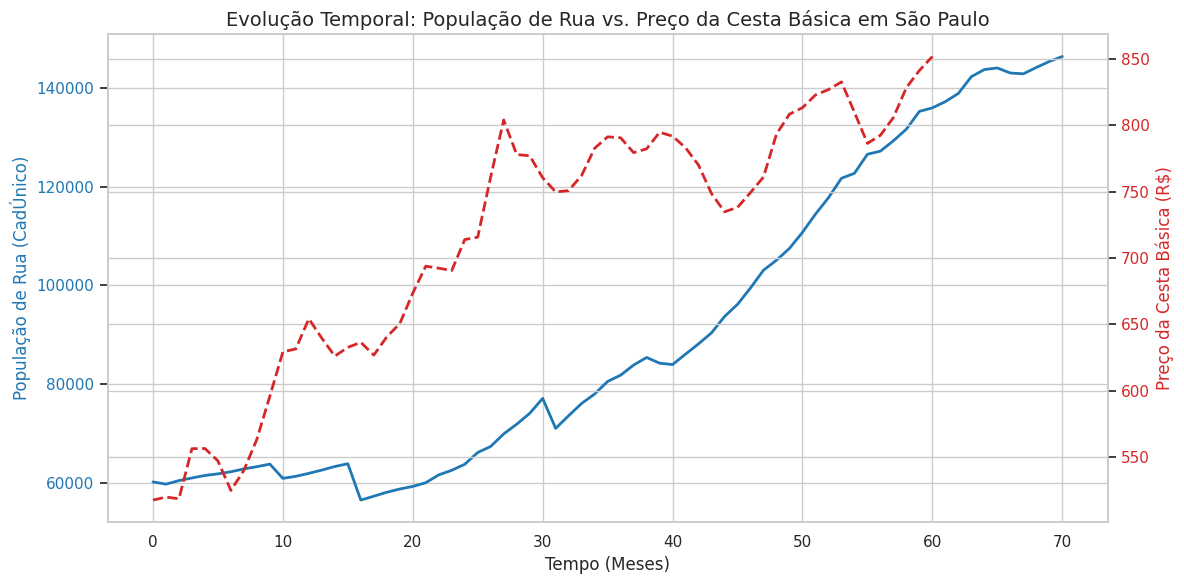

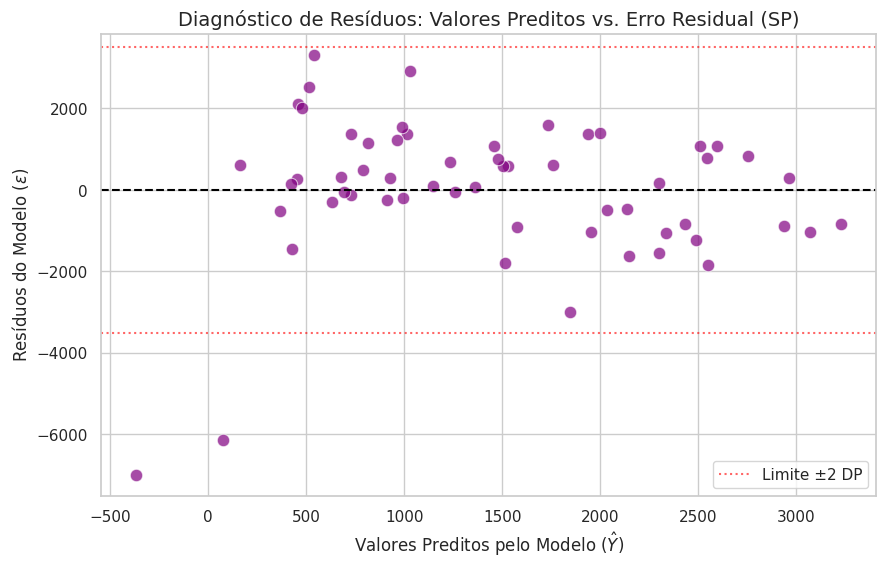

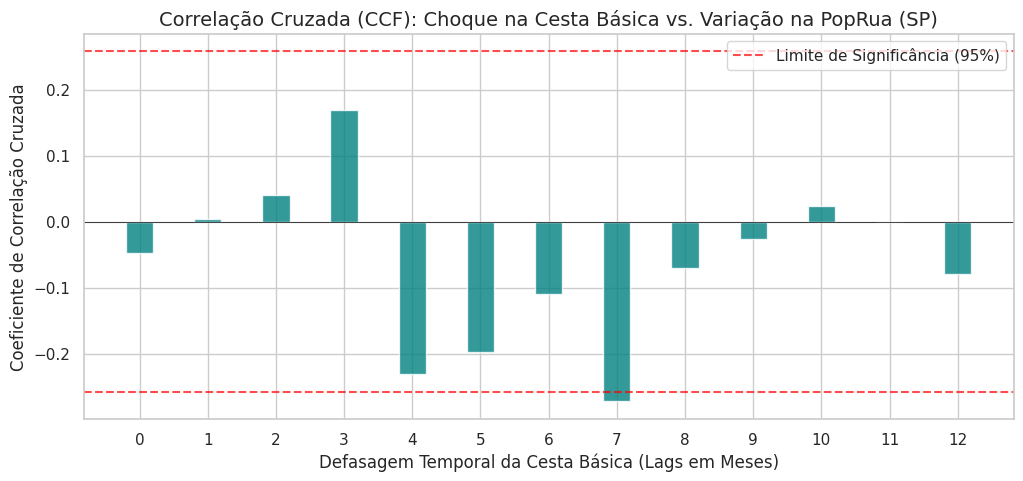

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import ccf

# Configuração estética geral dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# ================================================================================
# GRÁFICO 1: SÉRIES TEMPORAIS EM NÍVEL COM EIXO Y DUPLO
# ================================================================================
fig, ax1 = plt.subplots(figsize=(12, 6))

color = '#1f77b4'
ax1.set_xlabel('Tempo (Meses)')
ax1.set_ylabel('População de Rua (CadÚnico)', color=color)
ax1.plot(final_data.index, final_data['PopRua_SP'], color=color, linewidth=2, label='PopRua SP')
ax1.tick_params(axis='y', labelcolor=color)

# Cria o segundo eixo compartilhando o mesmo eixo X
ax2 = ax1.twinx()
color = '#d62728'
ax2.set_ylabel('Preço da Cesta Básica (R$)', color=color)
ax2.plot(final_data.index, final_data['Cesta_SP'], color=color, linewidth=2, linestyle='--', label='Cesta SP')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evolução Temporal: População de Rua vs. Preço da Cesta Básica em São Paulo')
fig.tight_layout()
plt.show()


# ================================================================================
# GRÁFICO 2: RESÍDUOS VS. VALORES AJUSTADOS (ANÁLISE DE OUTLIERS)
# ================================================================================
# Extraindo os valores do modelo já ajustado anteriormente (model_sp)
valores_ajustados = model_sp.fittedvalues
residuos = model_sp.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=valores_ajustados, y=residuos, color='purple', alpha=0.7, s=80)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)

# Linhas de limite para identificar Outliers Críticos (2 desvios padrões)
std_resid = residuos.std()
plt.axhline(y=2*std_resid, color='red', linestyle=':', alpha=0.6, label='Limite ±2 DP')
plt.axhline(y=-2*std_resid, color='red', linestyle=':', alpha=0.6)

plt.xlabel('Valores Preditos pelo Modelo ($\hat{Y}$)')
plt.ylabel('Resíduos do Modelo ($\epsilon$)')
plt.title('Diagnóstico de Resíduos: Valores Preditos vs. Erro Residual (SP)')
plt.legend()
plt.show()


# ================================================================================
# GRÁFICO 3: FUNÇÃO DE CORRELAÇÃO CRUZADA (CCF)
# ================================================================================
# Calculando a correlação entre as séries estacionárias (em primeira diferença)
y_diff = final_data['PopRua_SP'].diff().dropna()
x_diff = final_data['Cesta_SP'].diff().dropna()

# Alinha os índices devido à perda do primeiro elemento pelo .diff()
comum_idx = y_diff.index.intersection(x_diff.index)
y_diff = y_diff.loc[comum_idx]
x_diff = x_diff.loc[comum_idx]

# Calcula CCF até 12 lags
cross_corr = ccf(y_diff, x_diff, adjusted=False)[:13]
lags = list(range(13))

plt.figure(figsize=(12, 5))
plt.bar(lags, cross_corr, color='teal', alpha=0.8, width=0.4)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Limite aproximado de significância estatística de Bartlett (95% de confiança)
limite = 2 / np.sqrt(len(y_diff))
plt.axhline(y=limite, color='red', linestyle='--', alpha=0.7, label='Limite de Significância (95%)')
plt.axhline(y=-limite, color='red', linestyle='--', alpha=0.7)

plt.xticks(lags)
plt.xlabel('Defasagem Temporal da Cesta Básica (Lags em Meses)')
plt.ylabel('Coeficiente de Correlação Cruzada')
plt.title('Correlação Cruzada (CCF): Choque na Cesta Básica vs. Variação na PopRua (SP)')
plt.legend()
plt.show()

<>:51: SyntaxWarning: invalid escape sequence '\h'
<>:52: SyntaxWarning: invalid escape sequence '\e'
<>:51: SyntaxWarning: invalid escape sequence '\h'
<>:52: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_2960/2474722177.py:51: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('Valores Preditos pelo Modelo ($\hat{Y}$)')
/tmp/ipykernel_2960/2474722177.py:52: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('Resíduos do Modelo ($\epsilon$)')


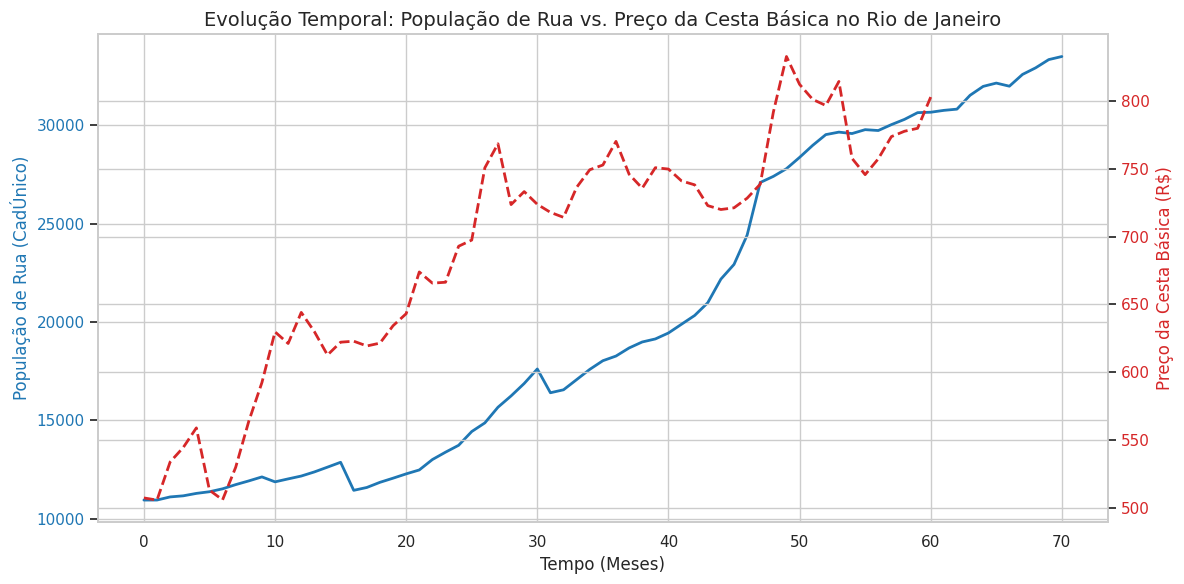

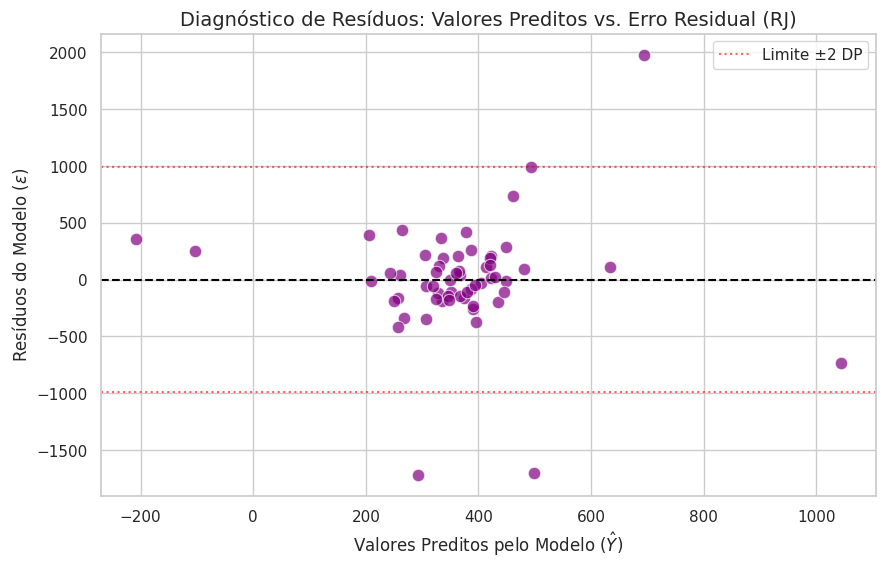

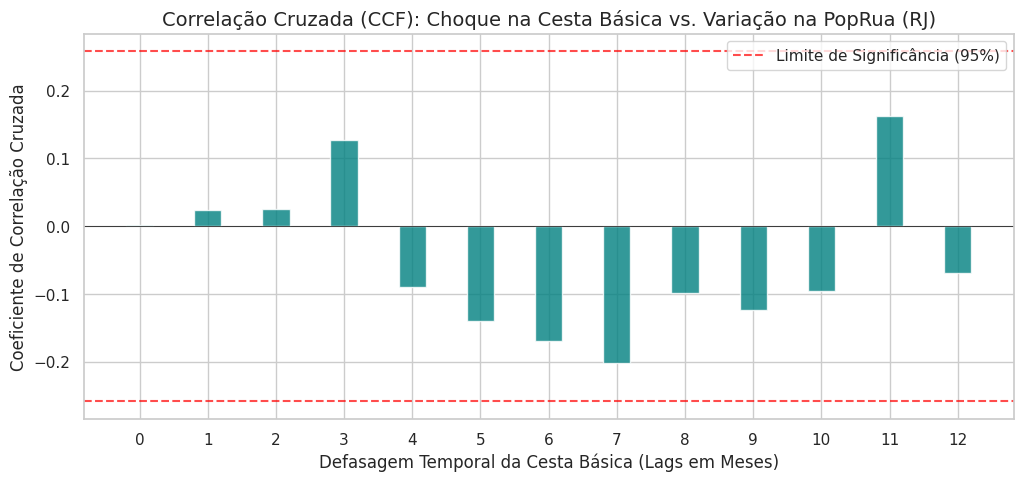

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import ccf

# Configuração estética geral dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# ================================================================================
# GRÁFICO 1: SÉRIES TEMPORAIS EM NÍVEL COM EIXO Y DUPLO
# ================================================================================
fig, ax1 = plt.subplots(figsize=(12, 6))

color = '#1f77b4'
ax1.set_xlabel('Tempo (Meses)')
ax1.set_ylabel('População de Rua (CadÚnico)', color=color)
ax1.plot(final_data.index, final_data['PopRua_RJ'], color=color, linewidth=2, label='PopRua RJ')
ax1.tick_params(axis='y', labelcolor=color)

# Cria o segundo eixo compartilhando o mesmo eixo X
ax2 = ax1.twinx()
color = '#d62728'
ax2.set_ylabel('Preço da Cesta Básica (R$)', color=color)
ax2.plot(final_data.index, final_data['Cesta_RJ'], color=color, linewidth=2, linestyle='--', label='Cesta SP')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evolução Temporal: População de Rua vs. Preço da Cesta Básica no Rio de Janeiro')
fig.tight_layout()
plt.show()


# ================================================================================
# GRÁFICO 2: RESÍDUOS VS. VALORES AJUSTADOS (ANÁLISE DE OUTLIERS)
# ================================================================================
# Extraindo os valores do modelo já ajustado anteriormente (model_sp)
valores_ajustados = model_rj.fittedvalues
residuos = model_rj.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=valores_ajustados, y=residuos, color='purple', alpha=0.7, s=80)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)

# Linhas de limite para identificar Outliers Críticos (2 desvios padrões)
std_resid = residuos.std()
plt.axhline(y=2*std_resid, color='red', linestyle=':', alpha=0.6, label='Limite ±2 DP')
plt.axhline(y=-2*std_resid, color='red', linestyle=':', alpha=0.6)

plt.xlabel('Valores Preditos pelo Modelo ($\hat{Y}$)')
plt.ylabel('Resíduos do Modelo ($\epsilon$)')
plt.title('Diagnóstico de Resíduos: Valores Preditos vs. Erro Residual (RJ)')
plt.legend()
plt.show()


# ================================================================================
# GRÁFICO 3: FUNÇÃO DE CORRELAÇÃO CRUZADA (CCF)
# ================================================================================
# Calculando a correlação entre as séries estacionárias (em primeira diferença)
y_diff = final_data['PopRua_RJ'].diff().dropna()
x_diff = final_data['Cesta_RJ'].diff().dropna()

# Alinha os índices devido à perda do primeiro elemento pelo .diff()
comum_idx = y_diff.index.intersection(x_diff.index)
y_diff = y_diff.loc[comum_idx]
x_diff = x_diff.loc[comum_idx]

# Calcula CCF até 12 lags
cross_corr = ccf(y_diff, x_diff, adjusted=False)[:13]
lags = list(range(13))

plt.figure(figsize=(12, 5))
plt.bar(lags, cross_corr, color='teal', alpha=0.8, width=0.4)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Limite aproximado de significância estatística de Bartlett (95% de confiança)
limite = 2 / np.sqrt(len(y_diff))
plt.axhline(y=limite, color='red', linestyle='--', alpha=0.7, label='Limite de Significância (95%)')
plt.axhline(y=-limite, color='red', linestyle='--', alpha=0.7)

plt.xticks(lags)
plt.xlabel('Defasagem Temporal da Cesta Básica (Lags em Meses)')
plt.ylabel('Coeficiente de Correlação Cruzada')
plt.title('Correlação Cruzada (CCF): Choque na Cesta Básica vs. Variação na PopRua (RJ)')
plt.legend()
plt.show()

<>:51: SyntaxWarning: invalid escape sequence '\h'
<>:52: SyntaxWarning: invalid escape sequence '\e'
<>:51: SyntaxWarning: invalid escape sequence '\h'
<>:52: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_2960/1386269731.py:51: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('Valores Preditos pelo Modelo ($\hat{Y}$)')
/tmp/ipykernel_2960/1386269731.py:52: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('Resíduos do Modelo ($\epsilon$)')


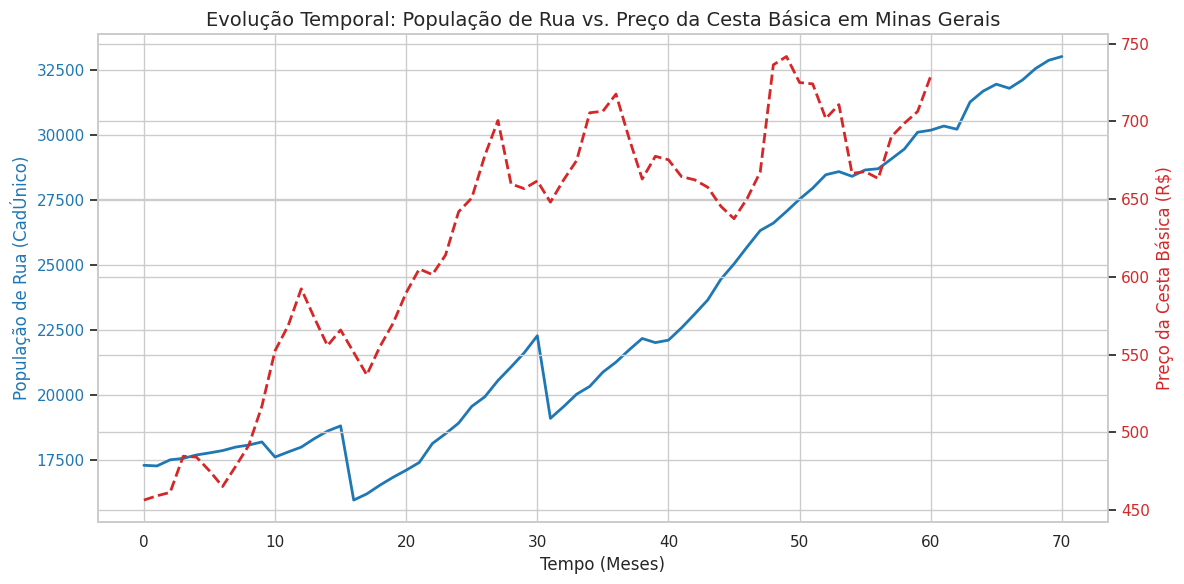

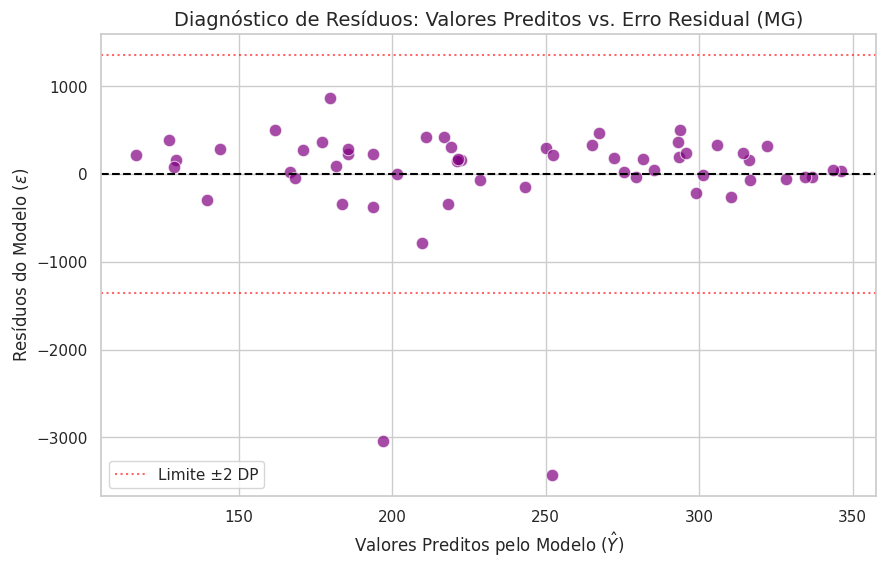

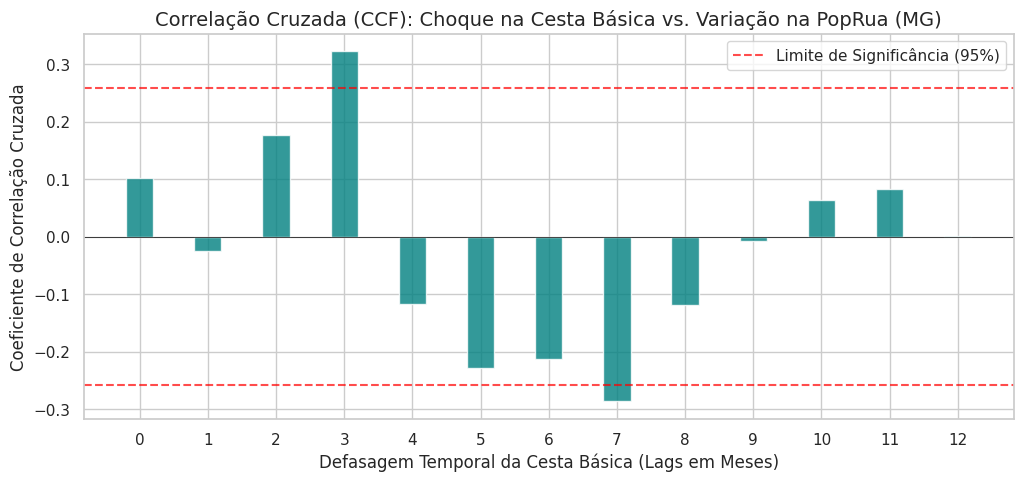

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import ccf

# Configuração estética geral dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# ================================================================================
# GRÁFICO 1: SÉRIES TEMPORAIS EM NÍVEL COM EIXO Y DUPLO
# ================================================================================
fig, ax1 = plt.subplots(figsize=(12, 6))

color = '#1f77b4'
ax1.set_xlabel('Tempo (Meses)')
ax1.set_ylabel('População de Rua (CadÚnico)', color=color)
ax1.plot(final_data.index, final_data['PopRua_MG'], color=color, linewidth=2, label='PopRua MG')
ax1.tick_params(axis='y', labelcolor=color)

# Cria o segundo eixo compartilhando o mesmo eixo X
ax2 = ax1.twinx()
color = '#d62728'
ax2.set_ylabel('Preço da Cesta Básica (R$)', color=color)
ax2.plot(final_data.index, final_data['Cesta_MG'], color=color, linewidth=2, linestyle='--', label='Cesta SP')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evolução Temporal: População de Rua vs. Preço da Cesta Básica em Minas Gerais')
fig.tight_layout()
plt.show()


# ================================================================================
# GRÁFICO 2: RESÍDUOS VS. VALORES AJUSTADOS (ANÁLISE DE OUTLIERS)
# ================================================================================
# Extraindo os valores do modelo já ajustado anteriormente (model_sp)
valores_ajustados = model_mg.fittedvalues
residuos = model_mg.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=valores_ajustados, y=residuos, color='purple', alpha=0.7, s=80)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)

# Linhas de limite para identificar Outliers Críticos (2 desvios padrões)
std_resid = residuos.std()
plt.axhline(y=2*std_resid, color='red', linestyle=':', alpha=0.6, label='Limite ±2 DP')
plt.axhline(y=-2*std_resid, color='red', linestyle=':', alpha=0.6)

plt.xlabel('Valores Preditos pelo Modelo ($\hat{Y}$)')
plt.ylabel('Resíduos do Modelo ($\epsilon$)')
plt.title('Diagnóstico de Resíduos: Valores Preditos vs. Erro Residual (MG)')
plt.legend()
plt.show()


# ================================================================================
# GRÁFICO 3: FUNÇÃO DE CORRELAÇÃO CRUZADA (CCF)
# ================================================================================
# Calculando a correlação entre as séries estacionárias (em primeira diferença)
y_diff = final_data['PopRua_MG'].diff().dropna()
x_diff = final_data['Cesta_MG'].diff().dropna()

# Alinha os índices devido à perda do primeiro elemento pelo .diff()
comum_idx = y_diff.index.intersection(x_diff.index)
y_diff = y_diff.loc[comum_idx]
x_diff = x_diff.loc[comum_idx]

# Calcula CCF até 12 lags
cross_corr = ccf(y_diff, x_diff, adjusted=False)[:13]
lags = list(range(13))

plt.figure(figsize=(12, 5))
plt.bar(lags, cross_corr, color='teal', alpha=0.8, width=0.4)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Limite aproximado de significância estatística de Bartlett (95% de confiança)
limite = 2 / np.sqrt(len(y_diff))
plt.axhline(y=limite, color='red', linestyle='--', alpha=0.7, label='Limite de Significância (95%)')
plt.axhline(y=-limite, color='red', linestyle='--', alpha=0.7)

plt.xticks(lags)
plt.xlabel('Defasagem Temporal da Cesta Básica (Lags em Meses)')
plt.ylabel('Coeficiente de Correlação Cruzada')
plt.title('Correlação Cruzada (CCF): Choque na Cesta Básica vs. Variação na PopRua (MG)')
plt.legend()
plt.show()

<>:51: SyntaxWarning: invalid escape sequence '\h'
<>:52: SyntaxWarning: invalid escape sequence '\e'
<>:51: SyntaxWarning: invalid escape sequence '\h'
<>:52: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_2960/1328171204.py:51: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('Valores Preditos pelo Modelo ($\hat{Y}$)')
/tmp/ipykernel_2960/1328171204.py:52: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('Resíduos do Modelo ($\epsilon$)')


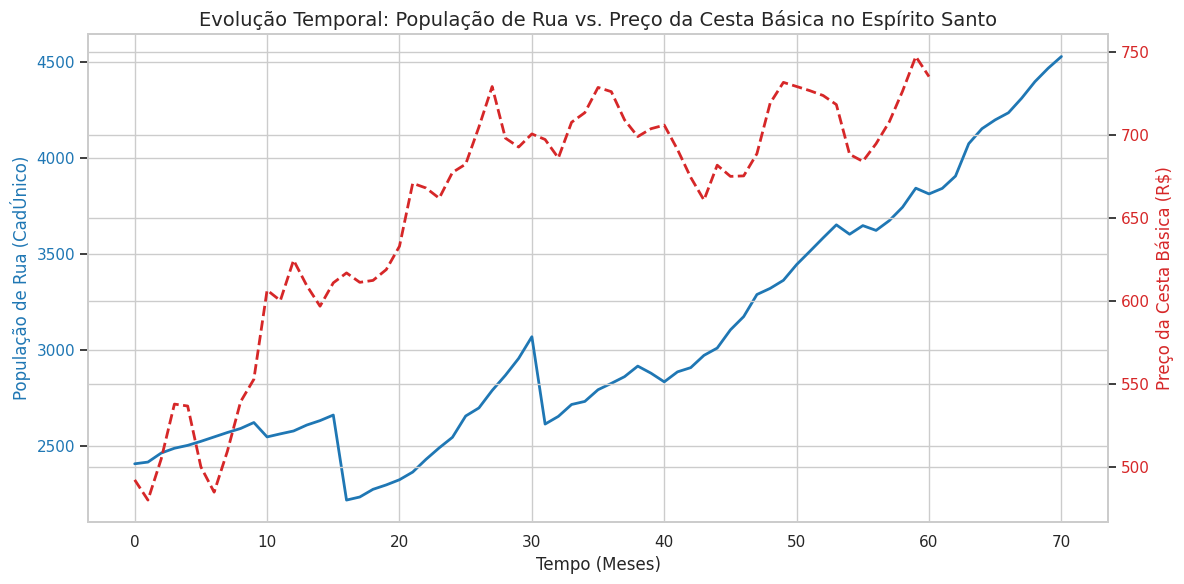

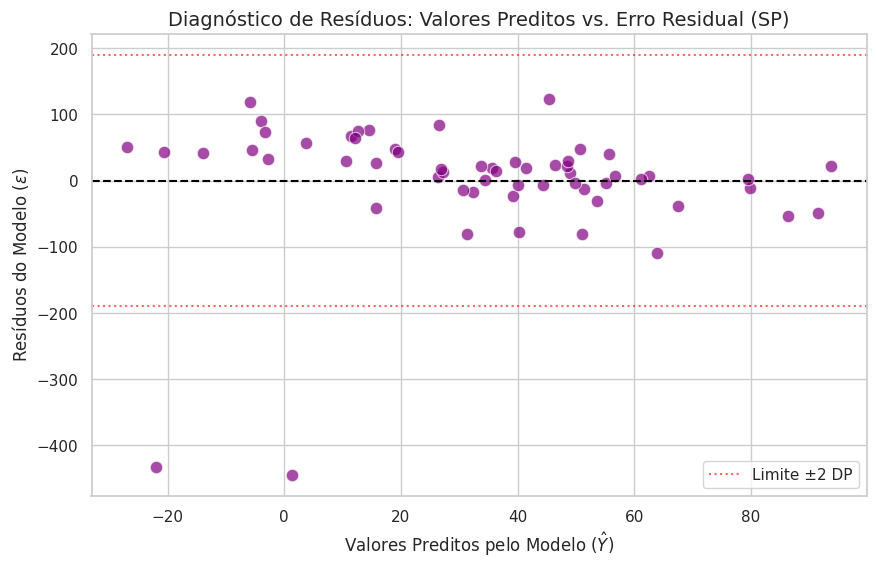

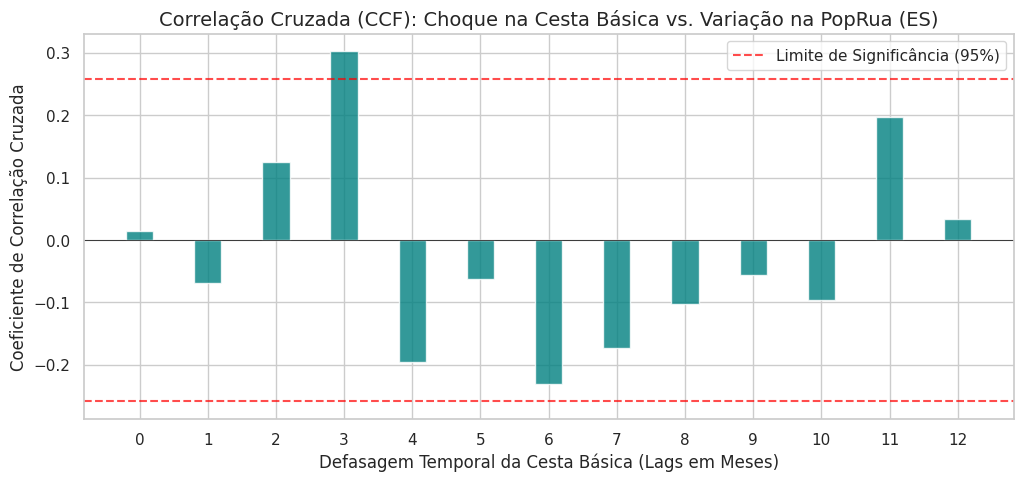

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import ccf

# Configuração estética geral dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# ================================================================================
# GRÁFICO 1: SÉRIES TEMPORAIS EM NÍVEL COM EIXO Y DUPLO
# ================================================================================
fig, ax1 = plt.subplots(figsize=(12, 6))

color = '#1f77b4'
ax1.set_xlabel('Tempo (Meses)')
ax1.set_ylabel('População de Rua (CadÚnico)', color=color)
ax1.plot(final_data.index, final_data['PopRua_ES'], color=color, linewidth=2, label='PopRua ES')
ax1.tick_params(axis='y', labelcolor=color)

# Cria o segundo eixo compartilhando o mesmo eixo X
ax2 = ax1.twinx()
color = '#d62728'
ax2.set_ylabel('Preço da Cesta Básica (R$)', color=color)
ax2.plot(final_data.index, final_data['Cesta_ES'], color=color, linewidth=2, linestyle='--', label='Cesta SP')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evolução Temporal: População de Rua vs. Preço da Cesta Básica no Espírito Santo')
fig.tight_layout()
plt.show()


# ================================================================================
# GRÁFICO 2: RESÍDUOS VS. VALORES AJUSTADOS (ANÁLISE DE OUTLIERS)
# ================================================================================
# Extraindo os valores do modelo já ajustado anteriormente (model_sp)
valores_ajustados = model_es.fittedvalues
residuos = model_es.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=valores_ajustados, y=residuos, color='purple', alpha=0.7, s=80)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)

# Linhas de limite para identificar Outliers Críticos (2 desvios padrões)
std_resid = residuos.std()
plt.axhline(y=2*std_resid, color='red', linestyle=':', alpha=0.6, label='Limite ±2 DP')
plt.axhline(y=-2*std_resid, color='red', linestyle=':', alpha=0.6)

plt.xlabel('Valores Preditos pelo Modelo ($\hat{Y}$)')
plt.ylabel('Resíduos do Modelo ($\epsilon$)')
plt.title('Diagnóstico de Resíduos: Valores Preditos vs. Erro Residual (SP)')
plt.legend()
plt.show()


# ================================================================================
# GRÁFICO 3: FUNÇÃO DE CORRELAÇÃO CRUZADA (CCF)
# ================================================================================
# Calculando a correlação entre as séries estacionárias (em primeira diferença)
y_diff = final_data['PopRua_ES'].diff().dropna()
x_diff = final_data['Cesta_ES'].diff().dropna()

# Alinha os índices devido à perda do primeiro elemento pelo .diff()
comum_idx = y_diff.index.intersection(x_diff.index)
y_diff = y_diff.loc[comum_idx]
x_diff = x_diff.loc[comum_idx]

# Calcula CCF até 12 lags
cross_corr = ccf(y_diff, x_diff, adjusted=False)[:13]
lags = list(range(13))

plt.figure(figsize=(12, 5))
plt.bar(lags, cross_corr, color='teal', alpha=0.8, width=0.4)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Limite aproximado de significância estatística de Bartlett (95% de confiança)
limite = 2 / np.sqrt(len(y_diff))
plt.axhline(y=limite, color='red', linestyle='--', alpha=0.7, label='Limite de Significância (95%)')
plt.axhline(y=-limite, color='red', linestyle='--', alpha=0.7)

plt.xticks(lags)
plt.xlabel('Defasagem Temporal da Cesta Básica (Lags em Meses)')
plt.ylabel('Coeficiente de Correlação Cruzada')
plt.title('Correlação Cruzada (CCF): Choque na Cesta Básica vs. Variação na PopRua (ES)')
plt.legend()
plt.show()